# 📊 QQQ Weekly Research — Predicción de Retornos y Construcción de Señales
## Pipeline: Dataset Parte 1 → Modelos de Retorno → Factores → Señales → Score → Backtests

---

**Objetivo:** Determinar si los features estructurales del mercado semanal de QQQ
— heredados de la Parte 1 — tienen poder predictivo sobre los retornos futuros
y si ese poder es suficiente para construir señales operativas con ventaja estadística.

**Contexto:** La Parte 1 mostró que el mercado presenta una estructura identificable
mediante clustering, permitiendo distinguir distintos contextos de mercado.
La pregunta que abre la Parte 2 es: ¿esa misma estructura predice *cuánto* sube el precio,
y no solo *en qué régimen* estamos? El proceso investigativo reveló que factores
estructurales como ATR y drawdown muestran relación histórica con el retorno futuro,
y que la señal ML `pred_prob_bull` (cobertura parcial) aporta información complementaria.
Combinar estos factores en un score continuo produce resultados in-sample mejores
que cualquier señal binaria individual.

Este notebook documenta ese recorrido de manera ordenada, con énfasis educativo.

---

## 🗺️ Mapa del Notebook

| # | Sección | Descripción |
|---|---------|-------------|
| 0 | **Setup y Datos** | Carga del dataset exportado en Parte 1 |
| 1 | **Feature Set** | Definición de features y preparación del modelo |
| 2 | **Baseline Regresión** | Regresión lineal y Random Forest sobre retorno continuo |
| 3 | **Clasificación Top Decil** | Predecir el top 10%/20% de retornos con RF |
| 4 | **Horizon Analysis** | ¿Para qué horizonte hay más señal? (4/12/24 semanas) |
| 5 | **Feature Selection** | Expansión V2 + consenso RF / Lasso / Ridge |
| 6 | **Single Factor Analysis** | Deciles y Spearman de los 3 factores analizados |
| 7 | **Factor Interactions** | Heatmaps de combinaciones de 2 factores |
| 8 | **Market States** | Definición de estados de mercado (ATR × Bull) |
| 9 | **Backtest Signal A** | Estrategia de seguimiento semanal |
| 10 | **Backtest Event-Driven** | Holding period fijo de 12 semanas |
| 11 | **Event Study** | Retorno acumulado promedio post-señal |
| 12 | **State Score V3** | Score compuesto ponderado |
| 13 | **Grid Search** | Optimización de pesos + resumen final |
| 14 | **Conclusiones** | Hallazgos clave |


---
## ⚙️ Parte 0 — Setup y Carga de Datos
### BLOQUE 0 — Librerías y dataset de entrada

Cargamos el dataset exportado de la Parte 1 (`qqq_part1_dataset.csv`).
Este archivo contiene el histórico semanal de QQQ con todos los features,
meta-estados, probabilidades y scores ya calculados.

**No hay descarga de datos en esta parte:** todo el pre-procesamiento
ocurrió en la Parte 1. Aquí consumimos ese output directamente.


In [ ]:
# ============================================================
# SETUP — Librerías y carga del dataset exportado en Parte 1
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score

pd.set_option("display.max_columns", None)

# ------------------------------------------------------------
# CARGAR DATASET (exportado de la Parte 1)
# ------------------------------------------------------------

df = pd.read_csv("qqq_part1_dataset.csv", index_col=0, parse_dates=True)

print(f"Shape  : {df.shape}")
print(f"Inicio : {df.index.min().date()}")
print(f"Fin    : {df.index.max().date()}")
print(f"Columnas ({len(df.columns)}):", df.columns.tolist())


Shape  : (1328, 60)
Inicio : 2001-01-05
Fin    : 2026-06-12
Columnas (60): ['Open', 'High', 'Low', 'Close', 'Volume', 'returns', 'log_returns', 'vol_4', 'vol_13', 'vol_26', 'mom_4', 'mom_13', 'mom_26', 'mom_52', 'sma_4', 'sma_13', 'sma_26', 'sma_52', 'trend_13_52', 'price_vs_sma_52', 'sma13_slope', 'high_13', 'low_13', 'breakout_13', 'breakdown_13', 'high_26', 'breakout_26', 'range_position_13', 'tr', 'atr_4', 'atr_13', 'atr_pct', 'cummax', 'drawdown', 'vol_rel_4', 'umap_1', 'umap_2', 'cluster', 'cluster_prob', 'fwd_ret_1', 'fwd_dd_1', 'fwd_ret_4', 'fwd_dd_4', 'fwd_ret_12', 'fwd_dd_12', 'fwd_ret_24', 'fwd_dd_24', 'meta_state', 'pred_prob_bull', 'feat_rsi', 'feat_bb', 'feat_sma', 'feat_mom', 'feat_bull', 'feat_conf', 'rsi14', 'mom63', 'trade_score', 'signature', 'signal']


---
## 📥 Parte 1 — Feature Set y Dataset de Modelado
### BLOQUE 1 — Definición de features y split temporal

Heredamos los features estructurales construidos en la Parte 1.
Los organizamos en 4 categorías base:

| Categoría | Features | Intuición |
|-----------|----------|-----------|
| **Espacial / Régimen** | cluster_prob, umap_1, umap_2 | Posición en el espacio latente UMAP |
| **Momentum** | mom_4/13/26/52 | Fuerza de la tendencia en distintas ventanas |
| **Tendencia** | trend_13_52, price_vs_sma_52, sma13_slope | Posición relativa al largo plazo |
| **Riesgo** | drawdown, atr_pct, trade_score | Caídas, amplitud y score compuesto |


**Target:** `fwd_ret_12` — retorno forward a 12 semanas.

**Split:** corte temporal en `2018-01-01` (sin shuffle). Es crítico hacerlo
así para evitar lookahead bias: el modelo nunca ve el futuro durante el entrenamiento.


Dataset: (1316, 14)

Distribución del target (fwd_ret_12):
count    1316.0000
mean        0.0303
std         0.1020
min        -0.4269
25%        -0.0179
50%         0.0413
75%         0.0912
max         0.4228
Name: fwd_ret_12, dtype: float64


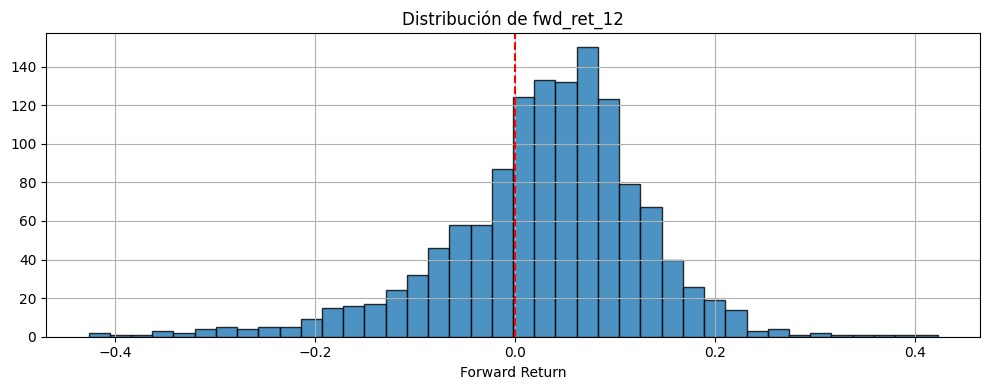


Train: (887, 14)  |  Test: (429, 14)


In [ ]:
# ============================================================
# FEATURE SET BASE Y PREPARACIÓN DEL DATASET
# ============================================================
# BASE_FEATURES excluye pred_prob_bull para mantener el dataset
# ============================================================

BASE_FEATURES = [
    # Espacial / Régimen (sin pred_prob_bull)
    "cluster_prob",
    "umap_1",
    "umap_2",
    # Momentum
    "mom_4", "mom_13", "mom_26", "mom_52",
    # Tendencia
    "trend_13_52", "price_vs_sma_52", "sma13_slope",
    # Riesgo
    "drawdown", "atr_pct",
    # Score compuesto (Parte 1)
    "trade_score",
]

TARGET     = "fwd_ret_12"
SPLIT_DATE = "2018-01-01"

# Dataset de modelado — dataset completo (~1315 observaciones)
df_model = df[BASE_FEATURES + [TARGET]].dropna().copy()

print(f"Dataset: {df_model.shape}")
print(f"\nDistribución del target ({TARGET}):")
print(df_model[TARGET].describe().round(4))

# Distribución visual
plt.figure(figsize=(10, 4))
plt.hist(df_model[TARGET], bins=40, edgecolor="black", alpha=0.8)
plt.axvline(0, color="red", linestyle="--")
plt.title(f"Distribución de {TARGET}")
plt.xlabel("Forward Return")
plt.grid(True)
plt.tight_layout()
plt.show()

# Train / test split
train = df_model[df_model.index <  SPLIT_DATE]
test  = df_model[df_model.index >= SPLIT_DATE]

X_train, y_train = train[BASE_FEATURES], train[TARGET]
X_test,  y_test  = test[BASE_FEATURES],  test[TARGET]

print(f"\nTrain: {train.shape}  |  Test: {test.shape}")


---
## 🔢 Parte 2 — Baseline de Predicción Continua
### BLOQUE 2 — Regresión lineal y Random Forest

Antes de clasificar, evaluamos si los features predicen el **retorno continuo**.
La pregunta es simple: ¿hay señal lineal o no lineal en los datos?

Probamos dos modelos:
- **Regresión Lineal:** captura relaciones aditivas entre features y retorno.
- **Random Forest Regressor:** captura interacciones no lineales y relaciones condicionales.

La métrica principal es **Spearman rank correlation** en lugar de R².
Spearman es más robusta en series financieras porque mide si el modelo
**ordena bien** las semanas, no si predice el valor exacto.

> Como referencia orientativa (no como umbral absoluto): en datos financieros
> semanales, Spearman por debajo de 0.05 generalmente no es actionable.
> Entre 0.10 y 0.20 es una señal débil pero informativa. Por encima de 0.20
> es inusual y merece análisis de robustez adicional.
> Cualquier resultado debe interpretarse considerando los costos de transacción.

**Nota:** un Spearman positivo estadísticamente significativo (p < 0.05)
es condición necesaria para construir señales, pero no suficiente.


LINEAR REGRESSION
----------------------------------------
MAE      : 0.0817
RMSE     : 0.1080
R²       : -0.2946
Spearman : -0.0568  (p=0.2407)

RANDOM FOREST REGRESSOR
----------------------------------------
MAE      : 0.0829
RMSE     : 0.1156
R²       : -0.4823
Spearman : -0.0645  (p=0.1822)

             Model  Spearman  P-value
Linear Regression   -0.0568   0.2407
    Random Forest   -0.0645   0.1822


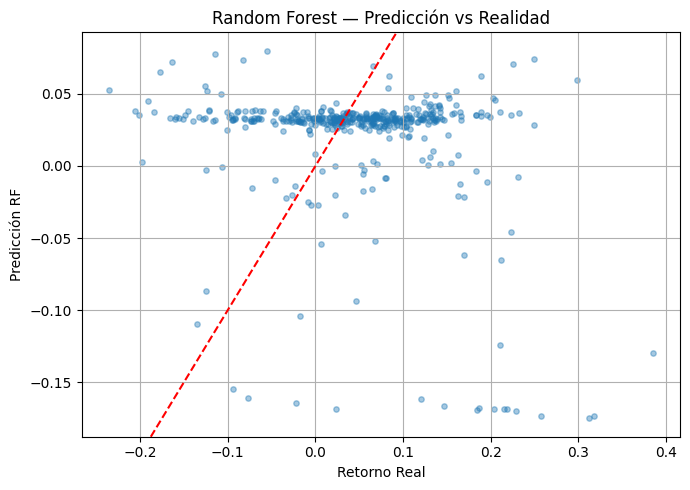

LR: Spearman=-0.0568 → Sin señal clara
RF: Spearman=-0.0645 → Sin señal clara


In [14]:
# ============================================================
# LINEAR REGRESSION
# ============================================================

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

spearman_lr, pval_lr = spearmanr(y_test, pred_lr)

print("LINEAR REGRESSION")
print("-" * 40)
print(f"MAE      : {mean_absolute_error(y_test, pred_lr):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, pred_lr)):.4f}")
print(f"R²       : {r2_score(y_test, pred_lr):.4f}")
print(f"Spearman : {spearman_lr:.4f}  (p={pval_lr:.4f})")

# Coeficientes
coef_df = (
    pd.DataFrame({"feature": BASE_FEATURES, "coef": lr.coef_})
    .assign(abs_coef=lambda x: x["coef"].abs())
    .sort_values("abs_coef", ascending=False)
)

# ============================================================
# RANDOM FOREST REGRESSOR
# ============================================================

rf = RandomForestRegressor(
    n_estimators=500, max_depth=5,
    min_samples_leaf=10, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

spearman_rf, pval_rf = spearmanr(y_test, pred_rf)

print("\nRANDOM FOREST REGRESSOR")
print("-" * 40)
print(f"MAE      : {mean_absolute_error(y_test, pred_rf):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, pred_rf)):.4f}")
print(f"R²       : {r2_score(y_test, pred_rf):.4f}")
print(f"Spearman : {spearman_rf:.4f}  (p={pval_rf:.4f})")

# ============================================================
# COMPARACIÓN Y DIAGNÓSTICO
# ============================================================

comparison = pd.DataFrame({
    "Model":    ["Linear Regression", "Random Forest"],
    "Spearman": [spearman_lr, spearman_rf],
    "P-value":  [pval_lr, pval_rf],
})
print("\n", comparison.round(4).to_string(index=False))

# Scatter: Predicción vs Real (RF)
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred_rf, alpha=0.4, s=15)
plt.xlabel("Retorno Real");  plt.ylabel("Predicción RF")
plt.title("Random Forest — Predicción vs Realidad")
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.grid(True); plt.tight_layout(); plt.show()

# Diagnóstico
for model_name, corr in [("LR", spearman_lr), ("RF", spearman_rf)]:
    if   corr < 0.05: verdict = "Sin señal clara"
    elif corr < 0.10: verdict = "Señal débil"
    elif corr < 0.20: verdict = "Señal interesante"
    else:             verdict = "Señal fuerte"
    print(f"{model_name}: Spearman={corr:.4f} → {verdict}")


---
## 🎯 Parte 3 — Clasificación del Top Decil de Retornos
### BLOQUE 3 — Random Forest clasificador

Reformulamos el problema: en lugar de predecir el retorno exacto,
predecimos si el retorno estará en el **top decil** de la distribución histórica.

**¿Por qué este enfoque?**
- Los retornos continuos son ruidosos — difíciles de predecir con precisión.
- Identificar las **mejores semanas para entrar** es suficiente para construir ventaja.
- La clasificación binaria es más estable y tiene métricas más claras (AUC, hit rate).

Comparamos dos umbrales:
- **Top 20%** (percentil 80): umbral más laxo, más observaciones positivas.
- **Top 10%** (percentil 90): umbral más exigente, separación más limpia.

La versión Top 10% resultó superior en AUC y spread de deciles —
es la que usamos para análisis posteriores.



  Top 20% (percentil 80)  (threshold=0.0966, 22.8% positivos)
  Umbral calculado sobre train set únicamente (sin lookahead)
  AUC              : 0.7205
  Top-Bottom spread: 0.0224
  Spearman (rank)  : 0.2662  (p=0.0000)

  Top 10% (percentil 90)  (threshold=0.1307, 12.3% positivos)
  Umbral calculado sobre train set únicamente (sin lookahead)
  AUC              : 0.7310
  Top-Bottom spread: 0.0327
  Spearman (rank)  : 0.3010  (p=0.0000)

→ Modelo seleccionado: Top10% (AUC 0.7310 vs 0.7205)
  Nota: selección ex-post basada en resultados — AUC puede estar sobreestimado.


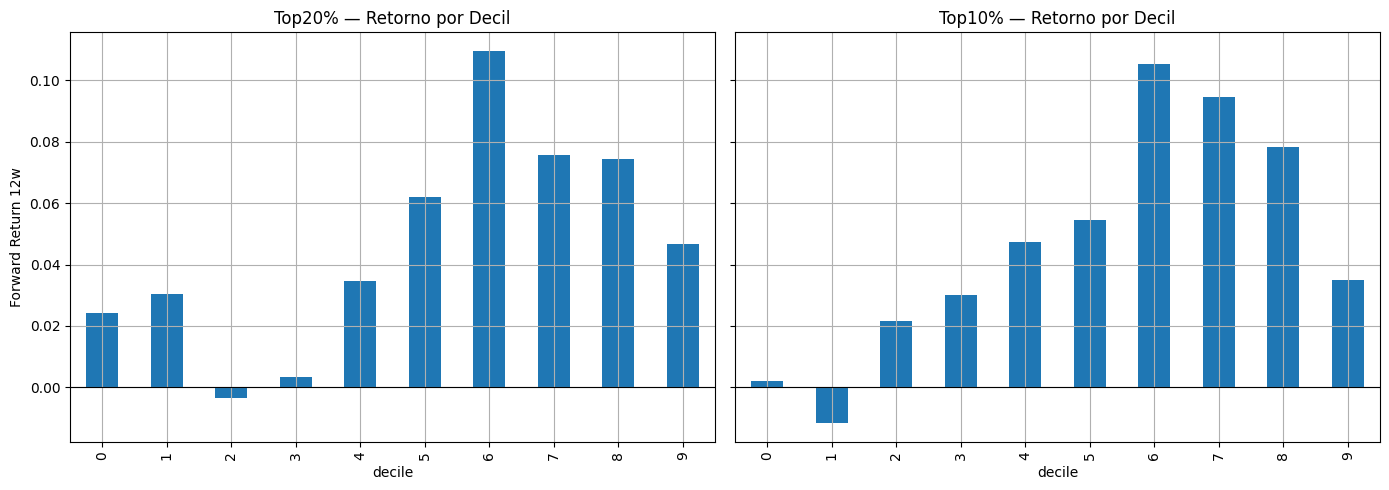

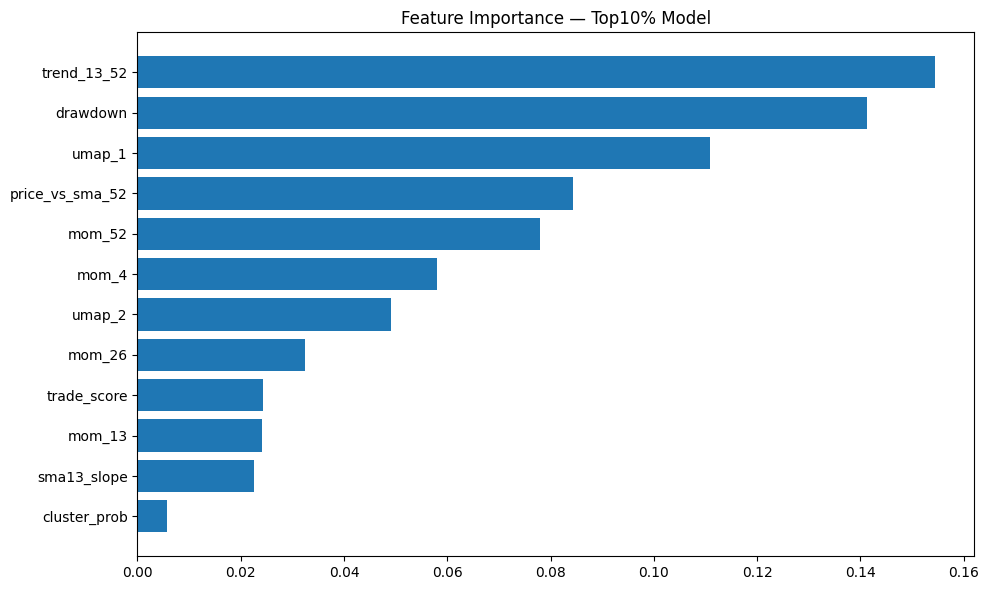

In [ ]:
# ============================================================
# CLASIFICACIÓN: TOP 20% vs TOP 10%
# ============================================================

def run_top_classifier(df_input, features, target_col, quantile, split_date, label):
    """Entrena RF clasificador para el top quantile% de retornos."""

    train = df_input[df_input.index <  split_date]
    test  = df_input[df_input.index >= split_date]

    # umbral calculado SOLO sobre train — evita lookahead bias
    threshold = train[target_col].quantile(quantile)
    temp = df_input.copy()
    temp["target"] = (temp[target_col] >= threshold).astype(int)

    train = temp[temp.index <  split_date]
    test  = temp[temp.index >= split_date]

    X_tr, y_tr = train[features], train["target"]
    X_te, y_te = test[features],  test["target"]

    clf = RandomForestClassifier(
        n_estimators=500, max_depth=5, min_samples_leaf=10,
        class_weight="balanced", random_state=42, n_jobs=-1
    )
    clf.fit(X_tr, y_tr)
    probs = clf.predict_proba(X_te)[:, 1]
    auc   = roc_auc_score(y_te, probs)

    # Deciles de probabilidad → retorno real
    results = pd.DataFrame({
        "prob":       probs,
        "fwd_ret_12": test[target_col].values
    })
    results["decile"] = pd.qcut(results["prob"], 10, labels=False, duplicates="drop")
    decile_ret = results.groupby("decile")["fwd_ret_12"].mean()
    spread = decile_ret.iloc[-1] - decile_ret.iloc[0]

    # Rank correlation: prob vs retorno real
    rank_corr, rank_p = spearmanr(results["prob"], results["fwd_ret_12"])

    # Feature importance
    imp = pd.DataFrame({
        "feature": features,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False)

    print(f"\n{'='*55}")
    print(f"  {label}  (threshold={threshold:.4f}, {temp['target'].mean():.1%} positivos)")
    print(f"  Umbral calculado sobre train set únicamente (sin lookahead)")
    print(f"{'='*55}")
    print(f"  AUC              : {auc:.4f}")
    print(f"  Top-Bottom spread: {spread:.4f}")
    print(f"  Spearman (rank)  : {rank_corr:.4f}  (p={rank_p:.4f})")

    return clf, probs, auc, decile_ret, imp, test

# ── Correr ambos modelos ──────────────────────────────────

clf20, probs20, auc20, deciles20, imp20, test20 = run_top_classifier(
    df_model, BASE_FEATURES, TARGET, 0.80, SPLIT_DATE, "Top 20% (percentil 80)")

clf10, probs10, auc10, deciles10, imp10, test10 = run_top_classifier(
    df_model, BASE_FEATURES, TARGET, 0.90, SPLIT_DATE, "Top 10% (percentil 90)")


print(f"\n→ Modelo seleccionado: Top10% (AUC {auc10:.4f} vs {auc20:.4f})")
print(f"  Nota: selección ex-post basada en resultados — AUC puede estar sobreestimado.")

# ── Visualización: deciles de retorno ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, deciles, title in [
    (axes[0], deciles20, "Top20% — Retorno por Decil"),
    (axes[1], deciles10, "Top10% — Retorno por Decil"),
]:
    deciles.plot(kind="bar", ax=ax)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title); ax.set_ylabel("Forward Return 12w"); ax.grid(True)
plt.tight_layout(); plt.show()

# ── Feature importance (modelo final Top10%) ──────────────

plt.figure(figsize=(10, 6))
plt.barh(imp10["feature"][::-1].head(12), imp10["importance"][::-1].head(12))
plt.title("Feature Importance — Top10% Model")
plt.tight_layout(); plt.show()

# Guardar variables para las secciones siguientes
clf_final, probs_final = clf10, probs10


---
## ⏱️ Parte 4 — Análisis por Horizonte Temporal
### BLOQUE 4 — Horizonte óptimo de predicción

¿Para qué horizonte tienen mayor poder predictivo los features estructurales?

Evaluamos 4, 12 y 24 semanas con el mismo modelo (Top 10% RF).
La intuición es que horizontes más largos pueden tener más señal
porque los regímenes son persistentes, pero también más ruido acumulado.

Medimos dos cosas por horizonte:
- **AUC:** capacidad discriminativa del modelo.
- **Top-Bottom spread:** diferencia de retorno entre el decil más alto
  y el más bajo de probabilidad predicha.

> **Nota de diseño:** independientemente del horizonte que muestre mayor AUC,
> el resto del proyecto mantiene `fwd_ret_12` como horizonte operativo principal
> por consistencia con los análisis de la Parte 1 y porque 12 semanas representa
> un ciclo tácticamente operativo. El análisis aquí es exploratorio.


   4w → AUC=0.7614  Top-Bottom spread=0.0220
  12w → AUC=0.7591  Top-Bottom spread=0.0420
  24w → AUC=0.8314  Top-Bottom spread=0.0986

  horizon     target    auc  spread
      24 fwd_ret_24 0.8314  0.0986
       4  fwd_ret_4 0.7614  0.0220
      12 fwd_ret_12 0.7591  0.0420


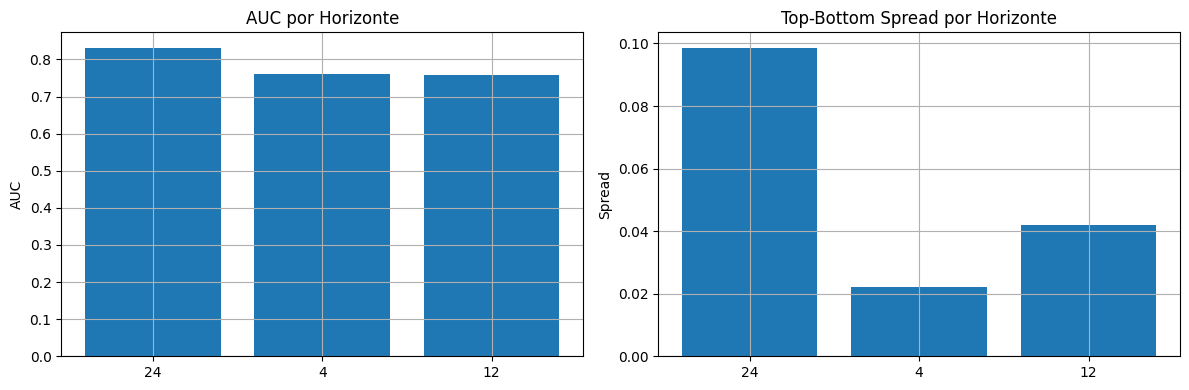


→ Horizonte con mayor AUC: 24w


In [16]:
# ============================================================
# HORIZON ANALYSIS — 4 / 12 / 24 SEMANAS
# ============================================================

TARGETS_H  = ["fwd_ret_4", "fwd_ret_12", "fwd_ret_24"]
HORIZONS   = [4, 12, 24]

df_horizon = df[BASE_FEATURES + TARGETS_H].dropna().copy()

results_horizons = []

for horizon, target_col in zip(HORIZONS, TARGETS_H):

    threshold = df_horizon[target_col].quantile(0.90)
    temp      = df_horizon.copy()
    temp["target"] = (temp[target_col] >= threshold).astype(int)

    train_h = temp[temp.index <  SPLIT_DATE]
    test_h  = temp[temp.index >= SPLIT_DATE]

    clf_h = RandomForestClassifier(
        n_estimators=500, max_depth=5, min_samples_leaf=10,
        class_weight="balanced", random_state=42, n_jobs=-1
    ).fit(train_h[BASE_FEATURES], train_h["target"])

    probs_h = clf_h.predict_proba(test_h[BASE_FEATURES])[:, 1]
    auc_h   = roc_auc_score(test_h["target"], probs_h)

    tmp = pd.DataFrame({"prob": probs_h, "ret": test_h[target_col].values})
    tmp["decile"] = pd.qcut(tmp["prob"], 10, labels=False, duplicates="drop")
    spread = tmp.groupby("decile")["ret"].mean()
    spread_val = spread.iloc[-1] - spread.iloc[0]

    results_horizons.append({
        "horizon": horizon, "target": target_col,
        "auc": auc_h, "spread": spread_val
    })
    print(f"  {horizon:2d}w → AUC={auc_h:.4f}  Top-Bottom spread={spread_val:.4f}")

summary_h = pd.DataFrame(results_horizons).sort_values("auc", ascending=False)
print("\n", summary_h.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(summary_h["horizon"].astype(str), summary_h["auc"])
axes[0].set_title("AUC por Horizonte"); axes[0].set_ylabel("AUC")
axes[1].bar(summary_h["horizon"].astype(str), summary_h["spread"])
axes[1].set_title("Top-Bottom Spread por Horizonte"); axes[1].set_ylabel("Spread")
for ax in axes: ax.grid(True)
plt.tight_layout(); plt.show()

print(f"\n→ Horizonte con mayor AUC: {summary_h.iloc[0]['horizon']}w")


---
## 🔬 Parte 5 — Feature Expansion y Selección por Consenso

Esta sección está dividida en dos etapas metodológicamente independientes.

**¿Por qué separarlas?**
`pred_prob_bull` solo tiene cobertura desde que existe el modelo XGBoost de la Parte 1,
lo que reduce el dataset de ~1315 a ~323 observaciones. Usar esa submuestra
para el ranking estructural contamina los resultados: cambia la población analizada,
el período histórico y las condiciones de mercado representadas.

---

### BLOQUE 5A — Ranking estructural de factores
**Dataset:** ~1315 observaciones — histórico completo
**Target:** `fwd_ret_12` — horizonte operativo oficial del proyecto
**Pregunta:** *¿Qué factores técnicos han sido históricamente robustos para explicar retornos a 12 semanas?*

Aplicamos RF + Lasso + Ridge sobre el dataset completo y construimos un
**ranking de consenso** que es el ranking oficial de robustez del proyecto.
`TOP_FACTORS` definido aquí alimenta todos los análisis de las Partes 6–11.

---

### BLOQUE 5B — Valor incremental de pred_prob_bull
**Dataset:** ~323 observaciones — subconjunto con cobertura de pred_prob_bull
**Target:** `fwd_ret_12`
**Pregunta:** *¿pred_prob_bull agrega información incremental sobre los factores estructurales ya descubiertos?*

Aquí sí aceptamos la reducción de muestra porque la pregunta ha cambiado:
no buscamos el ranking histórico sino el valor añadido de una variable específica
sobre el período donde existe.

> El resultado de 5A es el ranking oficial del proyecto.
> El resultado de 5B es una evaluación complementaria de pred_prob_bull.


ETAPA A — Dataset completo
  Observaciones : 1316
  Features      : 13
  Target        : fwd_ret_12  (fwd_ret_12)
  Train         : 887 obs
  Test          : 429 obs

RF (ETAPA A) — AUC: 0.7596

Ranking de consenso estructural (RF + Lasso + Ridge | ~1315 obs):


,feature,rf_importance,lasso_abs,ridge_abs,avg_rank
10,drawdown,0.1319,2.0345,2.0195,1.6667
8,price_vs_sma_52,0.0977,1.5276,1.1579,2.6667
11,atr_pct,0.2104,0.5686,0.5742,3.6667
2,umap_2,0.0549,0.7900,0.7609,4.6667
4,mom_13,0.0313,0.4817,0.7450,6.3333
5,mom_26,0.0308,0.5288,0.5951,6.6667
7,trend_13_52,0.1696,0.1000,0.5692,7.0000
6,mom_52,0.0755,0.2696,0.3203,7.6667
9,sma13_slope,0.0227,0.3865,0.5442,8.6667
3,mom_4,0.0642,0.1454,0.2247,9.0000



Features eliminadas por Lasso (coef=0): []

TOP_FACTORS (ranking oficial): ['drawdown', 'price_vs_sma_52', 'atr_pct', 'umap_2', 'mom_13']


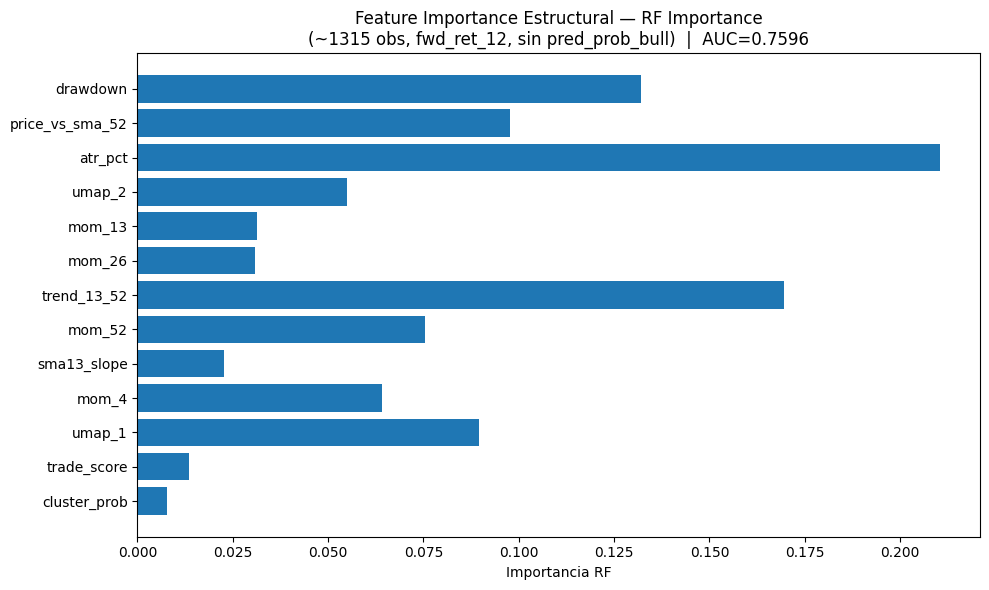

In [ ]:
# ============================================================
# PARTE 5A — RANKING ESTRUCTURAL DE FACTORES
# Dataset: df_model (~1315 obs) | Target: fwd_ret_12
# Sin pred_prob_bull — muestra histórica completa
# ============================================================

print("ETAPA A — Dataset completo")
print(f"  Observaciones : {df_model.shape[0]}")
print(f"  Features      : {len(BASE_FEATURES)}")
print(f"  Target        : {TARGET}  (fwd_ret_12)")

# ── Preparar target binario (Top 10%) ────────────────────

threshold_a      = df_model[TARGET].quantile(0.90)
df_model_a       = df_model.copy()
df_model_a["target"] = (df_model_a[TARGET] >= threshold_a).astype(int)

train_a = df_model_a[df_model_a.index <  SPLIT_DATE]
test_a  = df_model_a[df_model_a.index >= SPLIT_DATE]

print(f"  Train         : {train_a.shape[0]} obs")
print(f"  Test          : {test_a.shape[0]} obs")

# ── Random Forest ─────────────────────────────────────────

clf_a = RandomForestClassifier(
    n_estimators=500, max_depth=5, min_samples_leaf=10,
    class_weight="balanced", random_state=42, n_jobs=-1
).fit(train_a[BASE_FEATURES], train_a["target"])

prob_a = clf_a.predict_proba(test_a[BASE_FEATURES])[:, 1]
auc_a  = roc_auc_score(test_a["target"], prob_a)
print(f"\nRF (ETAPA A) — AUC: {auc_a:.4f}")

# ── Lasso + Ridge sobre muestra completa ──────────────────

scaler_a     = StandardScaler()
X_tr_a_sc    = scaler_a.fit_transform(train_a[BASE_FEATURES])
X_te_a_sc    = scaler_a.transform(test_a[BASE_FEATURES])

lasso_a = LogisticRegression(
    penalty="l1", solver="liblinear", random_state=42, max_iter=5000
).fit(X_tr_a_sc, train_a["target"])

ridge_a = LogisticRegression(
    penalty="l2", random_state=42, max_iter=5000
).fit(X_tr_a_sc, train_a["target"])

# ── Ranking de consenso ───────────────────────────────────

consensus_a = pd.DataFrame({
    "feature":       BASE_FEATURES,
    "rf_importance": clf_a.feature_importances_,
    "lasso_abs":     np.abs(lasso_a.coef_[0]),
    "ridge_abs":     np.abs(ridge_a.coef_[0]),
})
consensus_a["rf_rank"]    = consensus_a["rf_importance"].rank(ascending=False)
consensus_a["lasso_rank"] = consensus_a["lasso_abs"].rank(ascending=False)
consensus_a["ridge_rank"] = consensus_a["ridge_abs"].rank(ascending=False)
consensus_a["avg_rank"]   = consensus_a[["rf_rank","lasso_rank","ridge_rank"]].mean(axis=1)
consensus_a = consensus_a.sort_values("avg_rank")

print("\nRanking de consenso estructural (RF + Lasso + Ridge | ~1315 obs):")
display(consensus_a[["feature","rf_importance","lasso_abs","ridge_abs","avg_rank"]].round(4))

eliminated_a = consensus_a[consensus_a["lasso_abs"] == 0]["feature"].tolist()
print(f"\nFeatures eliminadas por Lasso (coef=0): {eliminated_a}")

# TOP_FACTORS: ranking oficial del proyecto
TOP_FACTORS = consensus_a.head(5)["feature"].tolist()
print(f"\nTOP_FACTORS (ranking oficial): {TOP_FACTORS}")

# ── Visualización ─────────────────────────────────────────

plt.figure(figsize=(10, 6))
plt.barh(consensus_a["feature"][::-1], consensus_a["rf_importance"][::-1])
plt.title(f"Feature Importance Estructural — RF Importance\n"
          f"(~1315 obs, fwd_ret_12, sin pred_prob_bull)  |  AUC={auc_a:.4f}")
plt.xlabel("Importancia RF")
plt.tight_layout()
plt.show()


### BLOQUE 5B — Valor incremental de pred_prob_bull (~323 obs)

El dataset se reduce al subconjunto donde `pred_prob_bull` tiene cobertura.
Evaluamos tres escenarios sobre esa misma submuestra para que la comparación
sea justa — el denominador es siempre el mismo período:

| Escenario | Features | n obs |
|-----------|----------|-------|
| Baseline técnico | BASE_FEATURES | ~323 |
| + Forecast ML | BASE_FEATURES + pred_prob_bull | ~323 |
| + Señales binarias | BASE_FEATURES + pred_prob_bull + señales | ~323 |

Si el AUC sube al agregar `pred_prob_bull` dentro de ese mismo subconjunto,
la variable aporta información incremental real sobre los factores técnicos.


ETAPA B — Dataset reducido por pred_prob_bull
  Observaciones : 317
  Train         : 257 obs
  Test          : 60 obs
  Target        : fwd_ret_12

Comparación de AUC — submuestra ~323 obs:
  BASE_FEATURES (sin pred_prob_bull)            AUC = 0.4405
  BASE + pred_prob_bull                         AUC = 0.4323
  BASE + pred_prob_bull + señales binarias      AUC = 0.4131

  Δ pred_prob_bull solo      : -0.0082
  Δ pred_prob_bull + señales : -0.0274

pred_prob_bull — posición en ranking 5B: 1.7 / 22


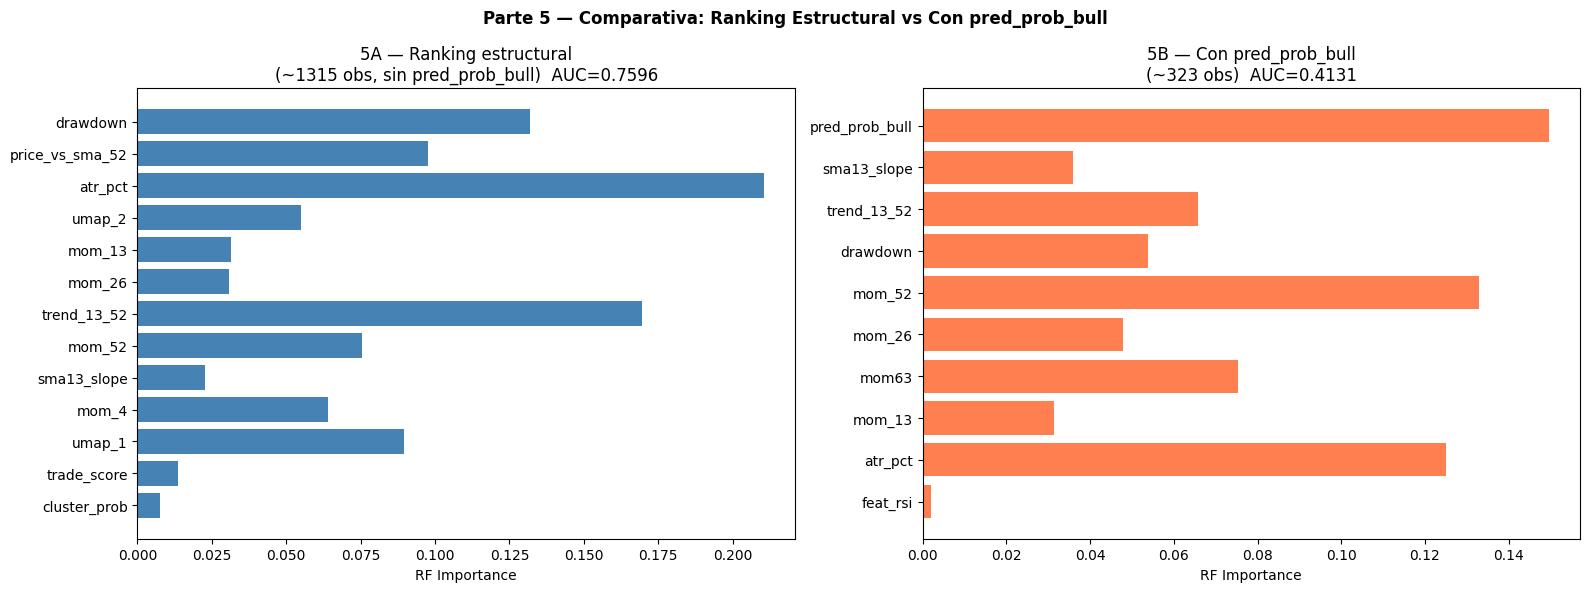


→ Ranking oficial del proyecto (TOP_FACTORS): ['drawdown', 'price_vs_sma_52', 'atr_pct', 'umap_2', 'mom_13']
  Derivado de ETAPA A (~1315 obs) — no afectado por pred_prob_bull


In [18]:
# ============================================================
# PARTE 5B — VALOR INCREMENTAL DE pred_prob_bull
# Dataset: ~323 obs (cobertura de pred_prob_bull) | Target: fwd_ret_12
# ============================================================

FEATURES_PLUS  = BASE_FEATURES + ["pred_prob_bull"]
FEATURES_FULL  = BASE_FEATURES + [
    "pred_prob_bull",
    "feat_rsi", "feat_bb", "feat_sma", "feat_mom", "feat_bull", "feat_conf",
    "rsi14", "mom63",
]

# Dataset reducido — mismo target que el proyecto (fwd_ret_12)
df_b = df[FEATURES_FULL + [TARGET]].dropna().copy()

threshold_b    = df_b[TARGET].quantile(0.90)
df_b["target"] = (df_b[TARGET] >= threshold_b).astype(int)

train_b = df_b[df_b.index <  SPLIT_DATE]
test_b  = df_b[df_b.index >= SPLIT_DATE]

print(f"ETAPA B — Dataset reducido por pred_prob_bull")
print(f"  Observaciones : {df_b.shape[0]}")
print(f"  Train         : {train_b.shape[0]} obs")
print(f"  Test          : {test_b.shape[0]} obs")
print(f"  Target        : fwd_ret_12")

# ── Comparar AUC en tres escenarios sobre la MISMA submuestra ──

def run_rf_auc(feats, tr, te, label):
    clf = RandomForestClassifier(
        n_estimators=500, max_depth=5, min_samples_leaf=10,
        class_weight="balanced", random_state=42, n_jobs=-1
    ).fit(tr[feats], tr["target"])
    prob = clf.predict_proba(te[feats])[:, 1]
    auc  = roc_auc_score(te["target"], prob)
    print(f"  {label:45s} AUC = {auc:.4f}")
    return clf, auc

print("\nComparación de AUC — submuestra ~323 obs:")
_,        auc_base = run_rf_auc(BASE_FEATURES, train_b, test_b,
                                "BASE_FEATURES (sin pred_prob_bull)")
_,        auc_plus = run_rf_auc(FEATURES_PLUS, train_b, test_b,
                                "BASE + pred_prob_bull")
clf_full, auc_full = run_rf_auc(FEATURES_FULL, train_b, test_b,
                                "BASE + pred_prob_bull + señales binarias")

print(f"\n  Δ pred_prob_bull solo      : {auc_plus - auc_base:+.4f}")
print(f"  Δ pred_prob_bull + señales : {auc_full - auc_base:+.4f}")

# ── Ranking de consenso 5B ────────────────────────────────

scaler_b     = StandardScaler()
X_tr_b_sc    = scaler_b.fit_transform(train_b[FEATURES_FULL])

lasso_b = LogisticRegression(
    penalty="l1", solver="liblinear", random_state=42, max_iter=5000
).fit(X_tr_b_sc, train_b["target"])

ridge_b = LogisticRegression(
    penalty="l2", random_state=42, max_iter=5000
).fit(X_tr_b_sc, train_b["target"])

consensus_b = pd.DataFrame({
    "feature":       FEATURES_FULL,
    "rf_importance": clf_full.feature_importances_,
    "lasso_abs":     np.abs(lasso_b.coef_[0]),
    "ridge_abs":     np.abs(ridge_b.coef_[0]),
})
consensus_b["rf_rank"]    = consensus_b["rf_importance"].rank(ascending=False)
consensus_b["lasso_rank"] = consensus_b["lasso_abs"].rank(ascending=False)
consensus_b["ridge_rank"] = consensus_b["ridge_abs"].rank(ascending=False)
consensus_b["avg_rank"]   = consensus_b[["rf_rank","lasso_rank","ridge_rank"]].mean(axis=1)
consensus_b = consensus_b.sort_values("avg_rank")

rank_prob = consensus_b[consensus_b["feature"]=="pred_prob_bull"]["avg_rank"].values[0]
print(f"\npred_prob_bull — posición en ranking 5B: {rank_prob:.1f} / {len(FEATURES_FULL)}")

# ── Gráfico comparativo 5A vs 5B ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(consensus_a["feature"][::-1], consensus_a["rf_importance"][::-1],
             color="steelblue")
axes[0].set_title(f"5A — Ranking estructural\n(~1315 obs, sin pred_prob_bull)  AUC={auc_a:.4f}")
axes[0].set_xlabel("RF Importance")

top10_b = consensus_b.head(10)
axes[1].barh(top10_b["feature"][::-1], top10_b["rf_importance"][::-1],
             color="coral")
axes[1].set_title(f"5B — Con pred_prob_bull\n(~323 obs)  AUC={auc_full:.4f}")
axes[1].set_xlabel("RF Importance")

plt.suptitle("Parte 5 — Comparativa: Ranking Estructural vs Con pred_prob_bull",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n→ Ranking oficial del proyecto (TOP_FACTORS): {TOP_FACTORS}")
print(f"  Derivado de ETAPA A (~1315 obs) — no afectado por pred_prob_bull")


---
## 📊 Parte 6 — Análisis Individual de Factores
### BLOQUE 6 — Deciles y correlación de Spearman

Analizamos tres factores: `atr_pct` y `drawdown` corresponden a los factores
top del ranking estructural de la Parte 5A. `pred_prob_bull` se analiza
aquí como factor suplementario proveniente del modelo ML de la Parte 1
(no pertenece al consenso estructural del 5A ya que se incorporó después).

Para cada factor calculamos:
- **Deciles:** retorno medio por cada decil del factor — ¿hay monotonía?
- **Spearman 12W y 24W:** ¿la señal persiste en horizontes más largos?
- **Top-Bottom spread:** diferencia de retorno entre el decil superior e inferior.

> **Advertencia de comparabilidad:** los Spearman no son directamente
> comparables entre factores. `atr_pct` y `drawdown` se calculan sobre
> ~1315 observaciones; `pred_prob_bull` sobre ~323 observaciones
> (período más reciente). Un Spearman mayor en una muestra más pequeña
> y más reciente no implica que el factor sea más predictivo históricamente.
> Se indica el `n` en cada caso.

Una relación **monótona** (el retorno sube o baja sistemáticamente a lo largo
de los deciles) es la evidencia más convincente de señal predictiva real.


Factor                 n obs  Spearman 12w  Spearman 24w
----------------------------------------------------------
atr_pct                 1316 +0.0790 (p=0.0041)  +0.0515 (p=0.0629)
pred_prob_bull           354 +0.0787 (p=0.1395)  +0.0722 (p=0.1751)
drawdown                1316 +0.0071 (p=0.7955)  +0.0547 (p=0.0485)


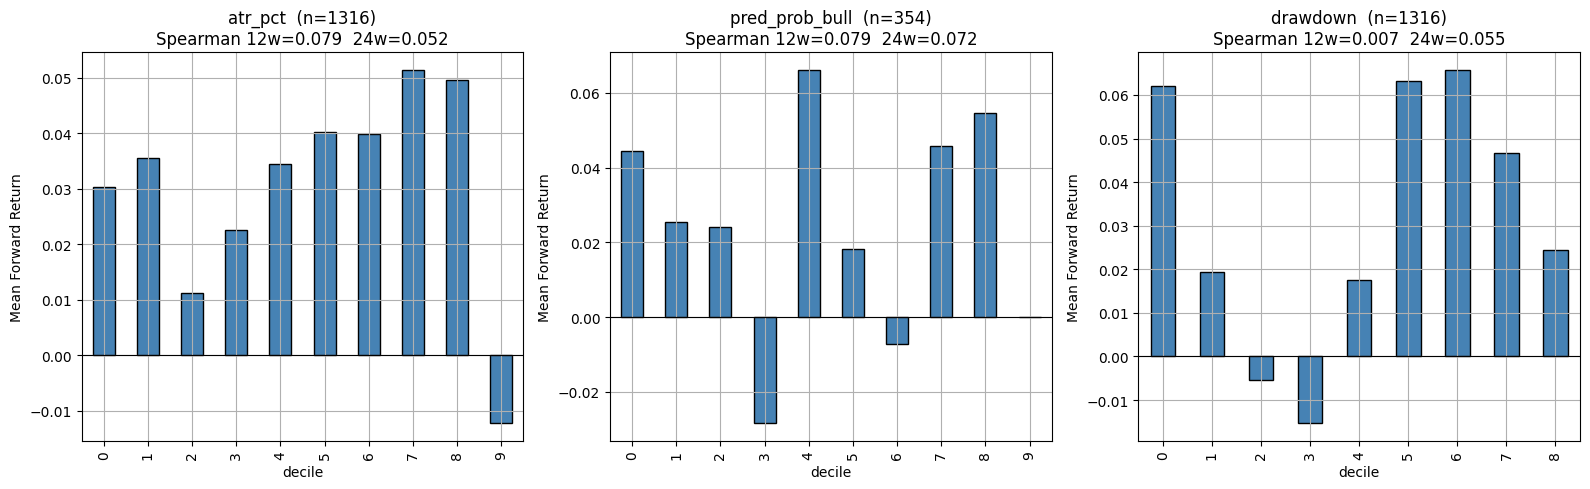


Top-Bottom decile spread (12w forward return):
  atr_pct             : -0.0426  (n=1316)
  pred_prob_bull      : -0.0444  (n=354)
  drawdown            : -0.0376  (n=1316)


In [19]:
# ============================================================
# SINGLE FACTOR ANALYSIS
# ============================================================

def analyze_factor(df_input, factor, target="fwd_ret_12"):
    """Deciles del factor vs retorno promedio y Spearman."""
    temp = df_input[[factor, target]].dropna().copy()
    temp["decile"] = pd.qcut(temp[factor], 10, labels=False, duplicates="drop")
    summary = temp.groupby("decile")[target].agg(["count","mean","median"])
    corr, pval = spearmanr(temp[factor], temp[target])
    n = len(temp)
    return summary, corr, pval, n

# atr_pct y drawdown: ranking estructural 5A (~1315 obs)
# pred_prob_bull: factor ML suplementario (~323 obs, período reciente)
TOP3 = ["atr_pct", "pred_prob_bull", "drawdown"]

print(f"{'Factor':20s} {'n obs':>7} {'Spearman 12w':>13} {'Spearman 24w':>13}")
print("-" * 58)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, factor in zip(axes, TOP3):
    summary, corr12, p12, n12 = analyze_factor(df, factor, "fwd_ret_12")
    _,       corr24, p24, _   = analyze_factor(df, factor, "fwd_ret_24")

    summary["mean"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{factor}  (n={n12})\nSpearman 12w={corr12:.3f}  24w={corr24:.3f}")
    ax.set_ylabel("Mean Forward Return")
    ax.grid(True)

    print(f"{factor:20s} {n12:>7d} {corr12:>+.4f} (p={p12:.4f})  {corr24:>+.4f} (p={p24:.4f})")

plt.tight_layout(); plt.show()

# Top/Bottom spread por factor
print("\nTop-Bottom decile spread (12w forward return):")
for factor in TOP3:
    temp = df[[factor, "fwd_ret_12"]].dropna().copy()
    n = len(temp)
    temp["decile"] = pd.qcut(temp[factor], 10, labels=False, duplicates="drop")
    decile_ret = temp.groupby("decile")["fwd_ret_12"].mean()
    spread = decile_ret.iloc[-1] - decile_ret.iloc[0]
    print(f"  {factor:20s}: {spread:+.4f}  (n={n})")


---
## 🔀 Parte 7 — Interacciones entre Factores
### BLOQUE 7 — Heatmaps de pares de factores

¿Dos factores juntos predicen mejor que cada uno por separado?

Dividimos cada factor en **quintiles (5 grupos)** y construimos
matrices de retorno promedio para cada combinación de quintiles.
Esto permite identificar:
- **Zonas calientes:** combinaciones donde el retorno futuro es muy superior al promedio.
- **Zonas frías:** combinaciones que hay que evitar.
- **Efectos de interacción:** si el efecto de un factor depende del nivel del otro.

Evaluamos los 3 pares posibles entre los factores analizados en la Parte 6
(ATR y drawdown como factores estructurales; pred_prob_bull como señal ML complementaria):
- ATR × Pred_Prob_Bull
- ATR × Drawdown
- Pred_Prob_Bull × Drawdown


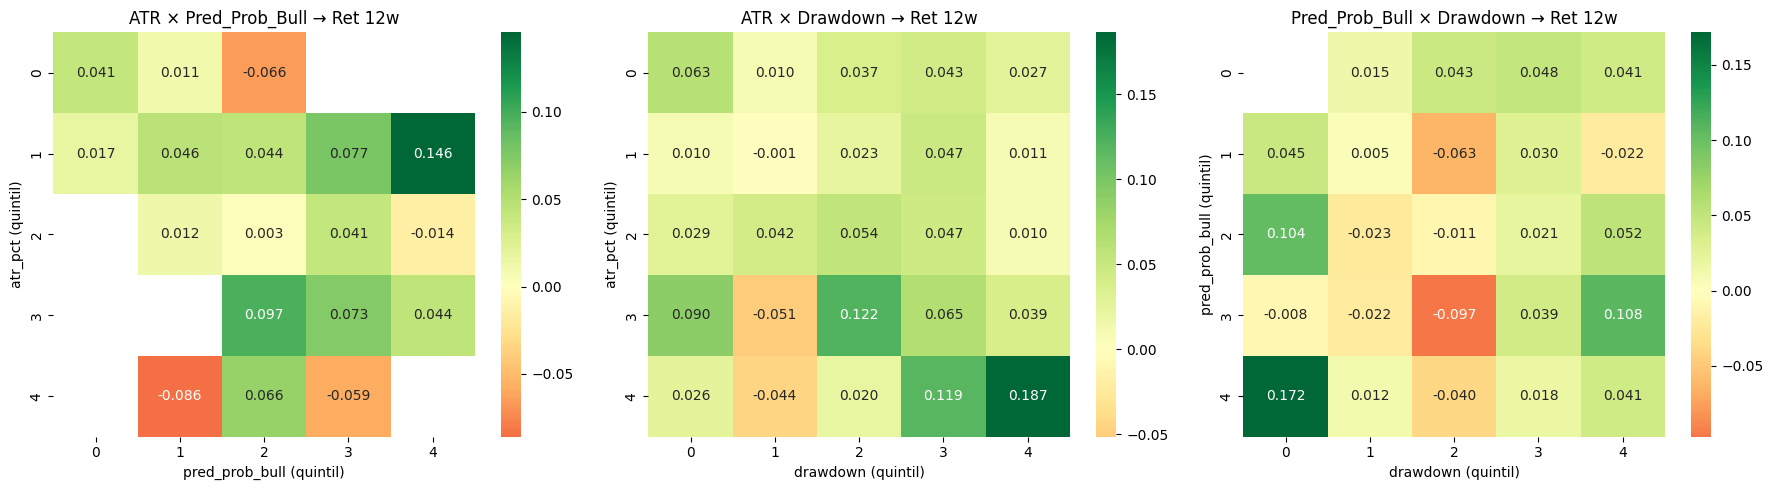


TOP / BOTTOM combinaciones (ATR × Bull):


,atr_bin_top,bull_bin_top,mean_return_top,n_obs_top,atr_bin_bottom,bull_bin_bottom,mean_return_bottom,n_obs_bottom
0,3,3,0.0734,20.0,4,1,-0.0859,22.0
1,4,2,0.0657,26.0,4,3,-0.0586,23.0
2,1,1,0.0465,33.0,2,4,-0.0140,24.0
3,1,2,0.0438,17.0,2,2,0.0025,19.0
4,3,4,0.0436,45.0,0,1,0.0110,15.0



TOP / BOTTOM combinaciones (ATR × Drawdown):


,atr_bin_top,dd_bin_top,mean_return_top,n_obs_top,atr_bin_bottom,dd_bin_bottom,mean_return_bottom,n_obs_bottom
0,3,2,0.1217,26,3,1,-0.0514,61
1,4,3,0.1191,16,4,1,-0.0442,52
2,3,0,0.0896,60,1,1,-0.0011,71
3,3,3,0.0651,80,0,1,0.0097,16
4,0,0,0.0627,10,2,4,0.0098,41



TOP / BOTTOM combinaciones (Bull × Drawdown):


,bull_bin_top,dd_bin_top,mean_return_top,n_obs_top,bull_bin_bottom,dd_bin_bottom,mean_return_bottom,n_obs_bottom
0,3,4,0.1077,17.0,1,2,-0.0634,18.0
1,2,0,0.1040,22.0,4,2,-0.0401,16.0
2,2,4,0.0524,17.0,2,1,-0.0227,10.0
3,0,3,0.0481,30.0,2,2,-0.0107,14.0
4,1,0,0.0447,13.0,3,0,-0.0078,30.0


In [ ]:
# ============================================================
# FACTOR INTERACTION HEATMAPS
# ============================================================

def interaction_heatmap(df_input, factor_x, factor_y, target, ax_table, ax_heat, title):
    temp = df_input[[factor_x, factor_y, target]].dropna().copy()
    temp["bin_x"] = pd.qcut(temp[factor_x], 5, labels=False, duplicates="drop")
    temp["bin_y"] = pd.qcut(temp[factor_y], 5, labels=False, duplicates="drop")

    pivot_mean  = temp.pivot_table(values=target, index="bin_x", columns="bin_y", aggfunc="mean")
    pivot_count = temp.pivot_table(values=target, index="bin_x", columns="bin_y", aggfunc="count")

    sns.heatmap(pivot_mean, annot=True, fmt=".3f", ax=ax_heat, center=0, cmap="RdYlGn")
    ax_heat.set_title(title)
    ax_heat.set_xlabel(f"{factor_y} (quintil)")
    ax_heat.set_ylabel(f"{factor_x} (quintil)")

    return pivot_mean, pivot_count


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

p1, c1 = interaction_heatmap(df, "atr_pct",       "pred_prob_bull", "fwd_ret_12",
                              None, axes[0], "ATR × Pred_Prob_Bull → Ret 12w")
p2, c2 = interaction_heatmap(df, "atr_pct",       "drawdown",       "fwd_ret_12",
                              None, axes[1], "ATR × Drawdown → Ret 12w")
p3, c3 = interaction_heatmap(df, "pred_prob_bull", "drawdown",       "fwd_ret_12",
                              None, axes[2], "Pred_Prob_Bull × Drawdown → Ret 12w")

plt.tight_layout(); plt.show()


def top_bottom_combos(pivot_mean, pivot_count, col_names, title, min_obs=10):
    """Top y bottom combinaciones de un heatmap, filtrando celdas vacías y poco pobladas."""

    stacked = pivot_mean.stack().reset_index()
    stacked.columns = col_names + ["mean_return"]

    count_stacked = pivot_count.stack().reset_index()
    count_stacked.columns = col_names + ["n_obs"]

    stacked = (
        stacked
        .merge(count_stacked, on=col_names)
        .dropna(subset=["mean_return"])        
        .query("n_obs >= @min_obs")            
        .sort_values("mean_return", ascending=False)
        .reset_index(drop=True)
    )

    if len(stacked) < 2:
        print(f"{title}: sin combinaciones robustas (min_obs={min_obs})")
        return

    top    = stacked.head(5).reset_index(drop=True)
    bottom = stacked.tail(5).sort_values("mean_return").reset_index(drop=True)

    top.columns    = [f"{c}_top"    for c in top.columns]
    bottom.columns = [f"{c}_bottom" for c in bottom.columns]

    print(f"\n{title}:")
    display(pd.concat([top, bottom], axis=1).round(4))


# ── ATR × Bull ────────────────────────────────────────────

top_bottom_combos(p1, c1, ["atr_bin",  "bull_bin"], "TOP / BOTTOM combinaciones (ATR × Bull)")

# ── ATR × Drawdown ────────────────────────────────────────

top_bottom_combos(p2, c2, ["atr_bin",  "dd_bin"],   "TOP / BOTTOM combinaciones (ATR × Drawdown)")

# ── Bull × Drawdown ───────────────────────────────────────

top_bottom_combos(p3, c3, ["bull_bin", "dd_bin"],   "TOP / BOTTOM combinaciones (Bull × Drawdown)")

---
## 🗂️ Parte 8 — Estados de Mercado
### BLOQUE 8 — Definición de estados: ATR × Pred_Prob_Bull

Utilizamos `atr_pct` y `pred_prob_bull` para construir un mapa de estados
de mercado mediante una grilla de quintiles. Dado que `pred_prob_bull`
tiene cobertura parcial, todos los análisis de esta sección en adelante
trabajan sobre el subconjunto de ~323 observaciones donde la variable existe.

De este análisis surgen estados históricamente favorables (**Signal A**)
y estados desfavorables (**Bad States**), definidos a partir de los retornos
observados en cada combinación ATR × Bull.

> **Advertencia de diseño:** los umbrales de Signal A (`atr_bin >= 3`,
> `bull_bin >= 2`) se eligieron observando los retornos históricos de
> cada celda de la grilla — selección ex-post. Con 25 combinaciones
> posibles (5×5), encontrar las "mejores" ex-post es esperable incluso
> bajo ruido puro. Los resultados deben interpretarse como hipótesis
> a validar, no como señales de eficacia demostrada.



Estados robustos (n≥20): 9

Top 10 estados:


,atr_bin,bull_bin,count,mean,median
13,3,3,20,0.0734,0.1028
16,4,2,26,0.0657,0.1028
4,1,1,33,0.0465,0.0601
14,3,4,45,0.0436,0.1010
10,2,3,26,0.0410,0.0627
0,0,0,54,0.0409,0.0420
11,2,4,24,-0.0140,0.0389
17,4,3,23,-0.0586,-0.1628
15,4,1,22,-0.0859,-0.0930



Retorno promedio mercado  : +0.0241
Signal A  (n=120)  mean=+0.0364  winrate=61.67%  alpha=+0.0123
Bad State (n= 36)  mean=+0.0220  winrate=61.11%
Signal A exposure: 33.90%


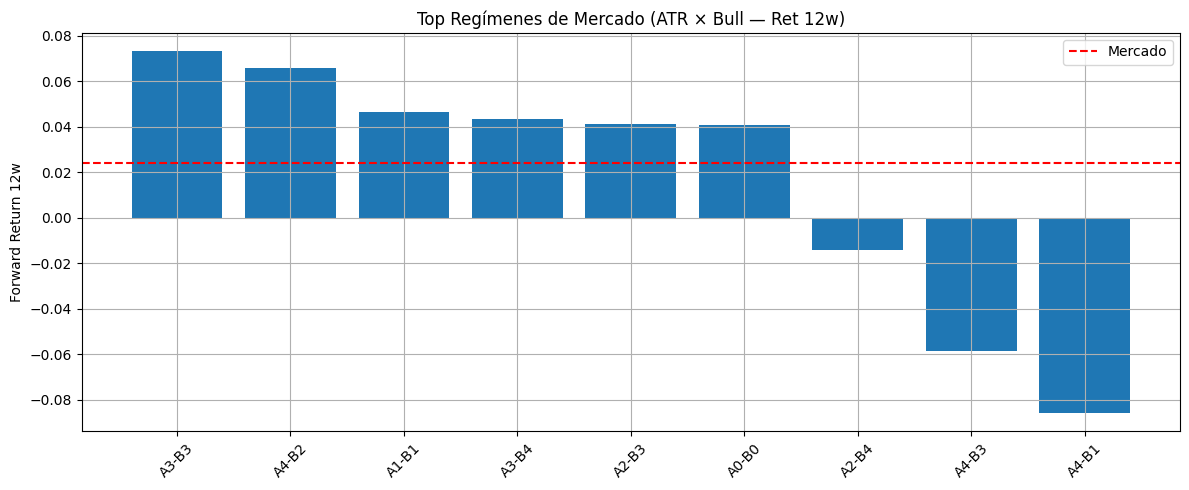

In [21]:
# ============================================================
# MARKET STATES — 3 FACTORES
# ============================================================

state_df = df[["atr_pct","pred_prob_bull","drawdown",
               "fwd_ret_12","fwd_ret_24","returns"]].dropna().copy()

state_df["atr_bin"]  = pd.qcut(state_df["atr_pct"],       5, labels=False)
state_df["bull_bin"] = pd.qcut(state_df["pred_prob_bull"], 5, labels=False, duplicates="drop")
state_df["dd_bin"]   = pd.qcut(state_df["drawdown"],       5, labels=False, duplicates="drop")

# ── Todos los estados (ATR × Bull) ────────────────────────

all_states = (
    state_df
    .groupby(["atr_bin","bull_bin"])["fwd_ret_12"]
    .agg(["count","mean","median"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

robust_states = all_states[all_states["count"] >= 20]

print(f"Estados robustos (n≥20): {len(robust_states)}")
print("\nTop 10 estados:")
display(robust_states.head(10).round(4))

# ── Signal A: estados favorables ──────────────────────────

state_df["signal_A"] = (
    (state_df["atr_bin"]  >= 3) &
    (state_df["bull_bin"] >= 2)
).astype(int)

# ── Bad States: estados a evitar ──────────────────────────

state_df["bad_state"] = (
    ((state_df["atr_bin"] == 1) & (state_df["bull_bin"] == 2)) |
    ((state_df["atr_bin"] == 2) & (state_df["bull_bin"] == 2))
).astype(int)

# Signal B: filtrar bad states
state_df["signal_B"] = (state_df["bad_state"] == 0).astype(int)

# ── Comparativa de retornos ───────────────────────────────

market_ret = state_df["fwd_ret_12"].mean()
signal_a   = state_df.loc[state_df["signal_A"]  == 1, "fwd_ret_12"]
bad_ret    = state_df.loc[state_df["bad_state"] == 1, "fwd_ret_12"]

print(f"\nRetorno promedio mercado  : {market_ret:+.4f}")
print(f"Signal A  (n={len(signal_a):3d})  mean={signal_a.mean():+.4f}  "
      f"winrate={(signal_a>0).mean():.2%}  "
      f"alpha={signal_a.mean()-market_ret:+.4f}")
print(f"Bad State (n={len(bad_ret):3d})  mean={bad_ret.mean():+.4f}  "
      f"winrate={(bad_ret>0).mean():.2%}")
print(f"Signal A exposure: {state_df['signal_A'].mean():.2%}")

# Plot top estados
top_states = robust_states.head(10)
plt.figure(figsize=(12, 5))
plt.bar(range(len(top_states)), top_states["mean"])
plt.xticks(range(len(top_states)),
           [f"A{int(a)}-B{int(b)}" for a,b in zip(top_states["atr_bin"],top_states["bull_bin"])],
           rotation=45)
plt.title("Top Regímenes de Mercado (ATR × Bull — Ret 12w)")
plt.ylabel("Forward Return 12w")
plt.axhline(market_ret, color="red", linestyle="--", label="Mercado")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


---
## 📈 Parte 9 — Backtesting
### Contexto: dos aproximaciones a la ejecución de Signal A

Signal A puede ejecutarse de dos formas operativamente distintas:

| Versión | Lógica de entrada | Lógica de salida | Exposición |
|---------|-------------------|------------------|------------|
| **Signal A continua** | Se activa cada semana que cumple la condición | Se cierra la semana que deja de cumplirse | Variable semana a semana |
| **Event-Driven 12W** | Se activa cuando aparece la condición | Se mantiene 12 semanas fijas | Fija desde la entrada |

La comparación de ambas versiones permite evaluar si la señal proviene
del estado de mercado en sí o de la transición de entrada a ese estado.

**Convención:** la posición del período t+1 se decide en el cierre de t. Sin lookahead.

### BLOQUE 9 — Backtest Signal A: seguimiento semanal


BACKTEST SIGNAL A — Métricas
-------------------------------------------------------
  Buy & Hold                 CAGR=-7.34%  MDD=-64.26%  Sharpe=-0.11
  Signal A                   CAGR=-4.45%  MDD=-68.27%  Sharpe=-0.10


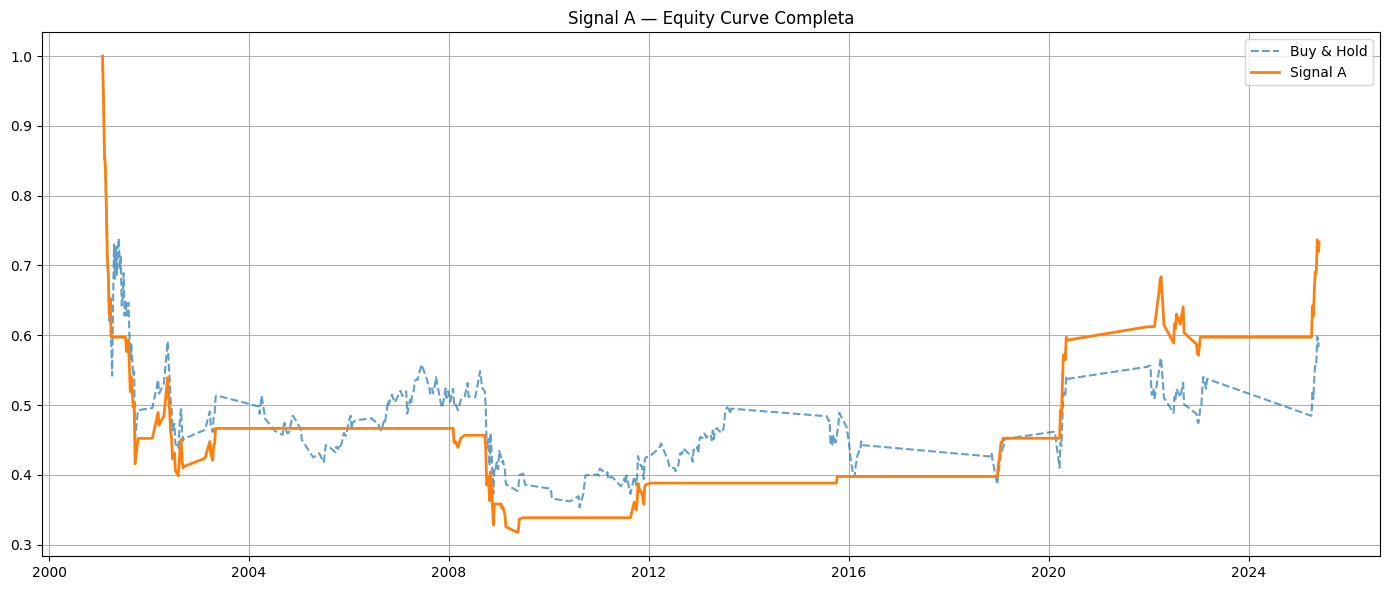

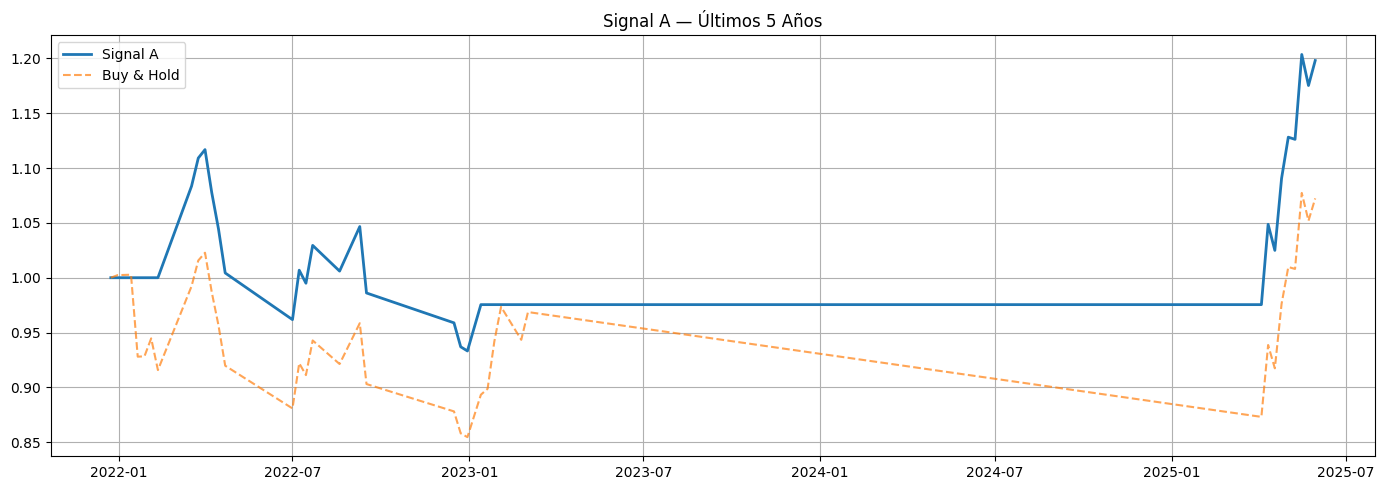

In [22]:
# ============================================================
# BACKTEST SIGNAL A — Seguimiento semanal
# ============================================================

def compute_metrics(equity, returns_series, label=""):
    years  = len(equity) / 52
    cagr   = equity.iloc[-1] ** (1/years) - 1
    mdd    = (equity / equity.cummax() - 1).min()
    sharpe = np.sqrt(52) * returns_series.mean() / returns_series.std()
    if label:
        print(f"  {label:25s}  CAGR={cagr:+.2%}  MDD={mdd:.2%}  Sharpe={sharpe:.2f}")
    return cagr, mdd, sharpe

bt = df.copy()
bt = bt.loc[state_df.index].copy()
bt["signal"] = state_df["signal_A"]

bt["strategy_ret"] = bt["signal"].shift(1).fillna(0) * bt["returns"]
bt["equity_strategy"] = (1 + bt["strategy_ret"].fillna(0)).cumprod()
bt["equity_buyhold"]  = (1 + bt["returns"]).cumprod()

print("BACKTEST SIGNAL A — Métricas")
print("-" * 55)
compute_metrics(bt["equity_buyhold"],  bt["returns"],       "Buy & Hold")
compute_metrics(bt["equity_strategy"], bt["strategy_ret"],  "Signal A")

# Equity curve completa
plt.figure(figsize=(14, 6))
plt.plot(bt.index, bt["equity_buyhold"],  label="Buy & Hold", alpha=0.7, linestyle="--")
plt.plot(bt.index, bt["equity_strategy"], label="Signal A",   linewidth=2)
plt.title("Signal A — Equity Curve Completa"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# Últimos 5 años
bt_recent = bt.loc[bt.index >= "2021-01-01"].copy()
plt.figure(figsize=(14, 5))
plt.plot(bt_recent.index, bt_recent["equity_strategy"] / bt_recent["equity_strategy"].iloc[0],
         label="Signal A", linewidth=2)
plt.plot(bt_recent.index, bt_recent["equity_buyhold"] / bt_recent["equity_buyhold"].iloc[0],
         label="Buy & Hold", linestyle="--", alpha=0.7)
plt.title("Signal A — Últimos 5 Años"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()


### BLOQUE 10 — Backtest event-driven: holding fijo de 12 semanas

Cuando aparece Signal A, abrimos posición y la mantenemos **exactamente
12 semanas** independientemente de si la señal sigue activa o no.

Esto modela un inversor que toma una decisión de entrada y la respeta,
sin salir ante el primer signo de debilidad. Reduce el ruido de corto plazo
pero puede mantener posición en semanas donde la señal ya no está activa.


BACKTEST EVENT-DRIVEN — Métricas
-------------------------------------------------------
  Buy & Hold                 CAGR=-7.34%  MDD=-64.26%  Sharpe=-0.11
  Event-Driven 12w           CAGR=-4.38%  MDD=-58.41%  Sharpe=-0.05
  Exposure: 46.33%


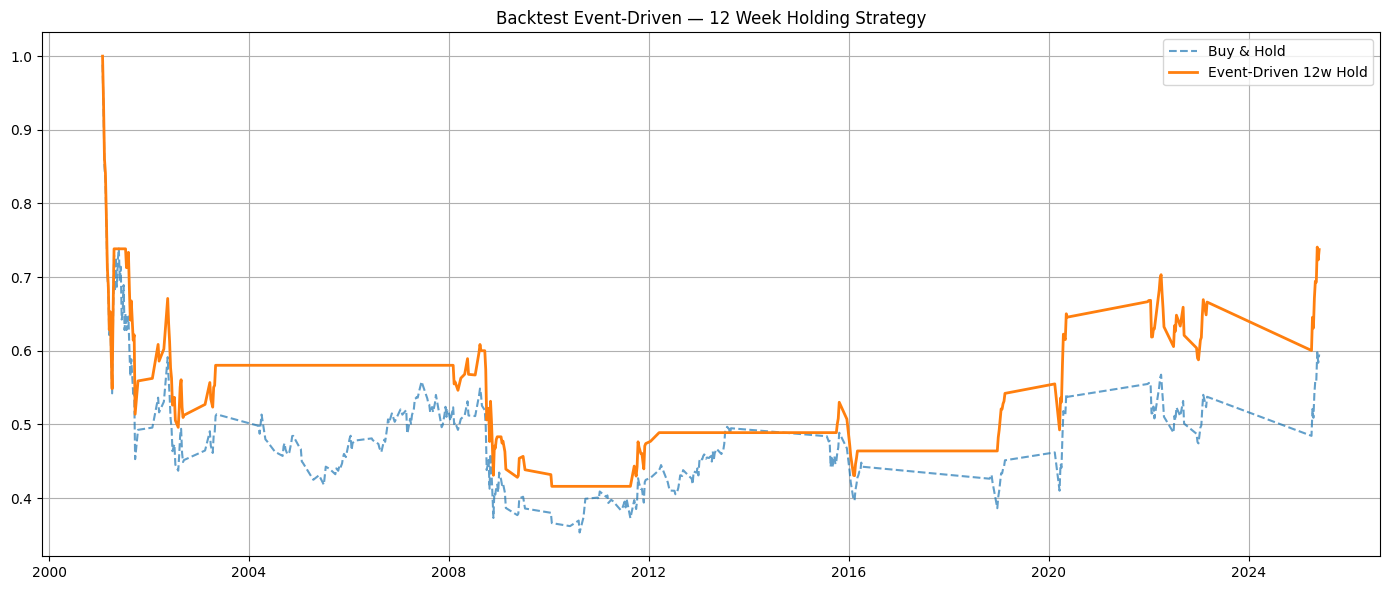

In [23]:
# ============================================================
# BACKTEST EVENT-DRIVEN — Holding 12 semanas
# ============================================================

HOLDING = 12

bt2 = df.copy()
bt2 = bt2.loc[state_df.index].copy()
bt2["signal"]   = state_df["signal_A"]
bt2["position"] = 0

in_trade   = False
weeks_left = 0

for i in range(len(bt2)):
    if not in_trade and bt2["signal"].iloc[i] == 1:
        in_trade   = True
        weeks_left = HOLDING
    if in_trade:
        bt2.iloc[i, bt2.columns.get_loc("position")] = 1
        weeks_left -= 1
        if weeks_left == 0:
            in_trade = False

bt2["strategy_ret"]   = bt2["position"].shift(1).fillna(0) * bt2["returns"]
bt2["equity_strategy"] = (1 + bt2["strategy_ret"].fillna(0)).cumprod()
bt2["equity_buyhold"]  = (1 + bt2["returns"]).cumprod()

print("BACKTEST EVENT-DRIVEN — Métricas")
print("-" * 55)
compute_metrics(bt2["equity_buyhold"],  bt2["returns"],        "Buy & Hold")
compute_metrics(bt2["equity_strategy"], bt2["strategy_ret"],   "Event-Driven 12w")
print(f"  Exposure: {bt2['position'].mean():.2%}")

plt.figure(figsize=(14, 6))
plt.plot(bt2.index, bt2["equity_buyhold"],  label="Buy & Hold", alpha=0.7, linestyle="--")
plt.plot(bt2.index, bt2["equity_strategy"], label="Event-Driven 12w Hold", linewidth=2)
plt.title("Backtest Event-Driven — 12 Week Holding Strategy")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


### BLOQUE 11 — Event study: retorno acumulado post-señal

Analizamos el retorno acumulado en las 12 semanas posteriores a cada
**activación de Signal A**, en dos variantes:

- **All weeks:** incluye cada semana donde Signal A está activa.
- **Entry only:** incluye solo las semanas de transición (de inactiva a activa).

> **Limitación estadística del all_weeks:** cuando Signal A permanece
> activa varias semanas seguidas, las ventanas de 12 semanas se solapan
> casi completamente. Esto viola la independencia entre observaciones —
> la media aparenta ser más estable de lo que realmente es porque las
> mismas semanas de retorno se cuentan múltiples veces. El análisis
> **entry_only** es estadísticamente más correcto y debe priorizarse
> para extraer conclusiones.

Esto complementa al backtest porque permite medir el comportamiento
promedio después de una entrada y detectar si los resultados dependen
de pocos eventos extremos (comparando media vs mediana).


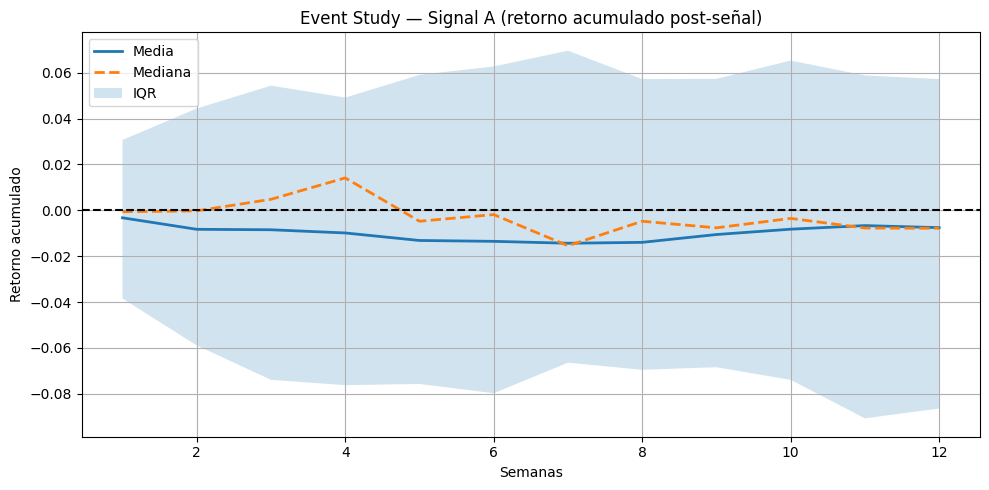

Eventos: 111  |  12w mean return: -0.0076


,mean,median
week,,
1,-0.0032,-0.0006
2,-0.0083,-0.0002
3,-0.0085,0.0048
4,-0.0099,0.0141
5,-0.0131,-0.0047
6,-0.0135,-0.0018
7,-0.0143,-0.0154
8,-0.0140,-0.0048
9,-0.0105,-0.0076


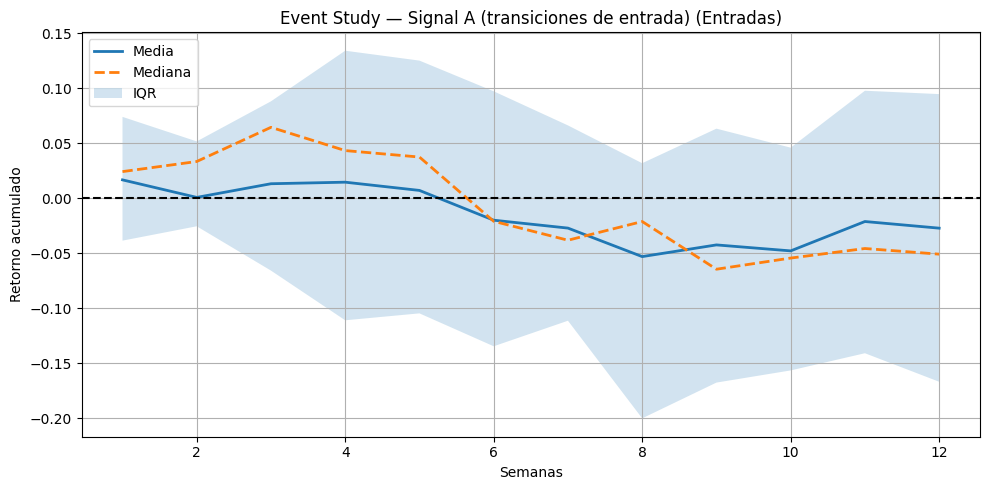

Eventos: 11  |  12w mean return: -0.0272


,mean,median
week,,
1,0.0167,0.0242
2,0.0007,0.0334
3,0.0132,0.0645
4,0.0146,0.0434
5,0.0071,0.0375
6,-0.0200,-0.0210
7,-0.0272,-0.0382
8,-0.0531,-0.0212
9,-0.0425,-0.0646



Comparación resumen:


,variant,n_events,12w_mean,12w_median
0,all_weeks,111,-0.0076,-0.0078
1,entry_only,11,-0.0272,-0.0509


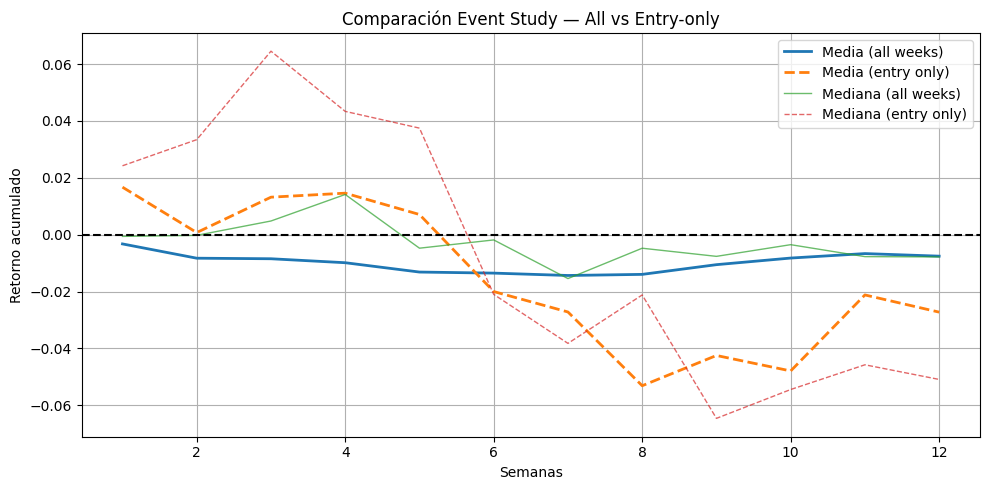

In [24]:
# ============================================================
# EVENT STUDY — Signal A (all-weeks vs entry-only)
# ============================================================

def run_event_study(df_events, signal_col, returns_col, horizon, title, entry_only=False):
    if entry_only:
        event_dates = df_events.index[(df_events[signal_col] == 1) &
                                      (df_events[signal_col].shift(1).fillna(0) == 0)]
    else:
        event_dates = df_events.index[df_events[signal_col] == 1]

    paths = []
    for date in event_dates:
        idx = df_events.index.get_loc(date)
        if idx + horizon < len(df_events):
            future = (1 + df_events[returns_col].iloc[idx+1 : idx+horizon+1]).cumprod() - 1
            paths.append(future.values)

    if not paths:
        print("Sin eventos suficientes"); return None

    paths     = np.array(paths)
    mean_path = paths.mean(axis=0)
    med_path  = np.median(paths, axis=0)
    weeks     = np.arange(1, horizon + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(weeks, mean_path,  label="Media",   linewidth=2)
    plt.plot(weeks, med_path,   label="Mediana", linewidth=2, linestyle="--")
    plt.fill_between(weeks,
                     np.percentile(paths, 25, axis=0),
                     np.percentile(paths, 75, axis=0), alpha=0.2, label="IQR")
    plt.axhline(0, linestyle="--", color="black")
    suffix = " (Entradas)" if entry_only else ""
    plt.title(f"{title}{suffix}")
    plt.xlabel("Semanas"); plt.ylabel("Retorno acumulado")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    summary = pd.DataFrame({"week": weeks, "mean": mean_path, "median": med_path})
    print(f"Eventos: {len(paths)}  |  12w mean return: {mean_path[-1]:+.4f}")
    display(summary.set_index("week").round(4))

    return {
        "event_count": len(paths),
        "mean_path": mean_path,
        "median_path": med_path,
        "paths": paths,
        "summary": summary.set_index("week")
    }

event_data = df.copy()
event_data = event_data.loc[state_df.index].copy()
event_data["signal_A"] = state_df["signal_A"]

res_all = run_event_study(event_data, "signal_A", "returns", 12,
                         "Event Study — Signal A (retorno acumulado post-señal)",
                         entry_only=False)

res_entries = run_event_study(event_data, "signal_A", "returns", 12,
                             "Event Study — Signal A (transiciones de entrada)",
                             entry_only=True)

# Comparación cuantitativa
if res_all is not None and res_entries is not None:
    print("\nComparación resumen:")
    comp = pd.DataFrame({
        "variant": ["all_weeks", "entry_only"],
        "n_events": [res_all["event_count"], res_entries["event_count"]],
        "12w_mean": [res_all["mean_path"][-1], res_entries["mean_path"][-1]],
        "12w_median": [res_all["median_path"][-1], res_entries["median_path"][-1]]
    })
    display(comp.round(4))

    # Gráfico comparado (media + mediana)
    weeks = np.arange(1, 12 + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(weeks, res_all["mean_path"], label="Media (all weeks)", linewidth=2)
    plt.plot(weeks, res_entries["mean_path"], label="Media (entry only)", linewidth=2, linestyle="--")
    plt.plot(weeks, res_all["median_path"], label="Mediana (all weeks)", linewidth=1, alpha=0.7)
    plt.plot(weeks, res_entries["median_path"], label="Mediana (entry only)", linewidth=1, alpha=0.7, linestyle="--")
    plt.axhline(0, linestyle="--", color="black")
    plt.title("Comparación Event Study — All vs Entry-only")
    plt.xlabel("Semanas"); plt.ylabel("Retorno acumulado")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


---
## 🏆 Parte 10 — State Score V3: Score Compuesto Ponderado
### BLOQUE 12 — Score continuo de tres factores

En lugar de señales binarias (dentro/fuera), construimos un **score continuo**
que combina tres factores como rankings normalizados (quintil 0–4):

```
state_score_v3 = 0.4 × atr_rank + 0.4 × bull_rank + 0.2 × trend_rank
```

Los pesos iniciales son un punto de partida razonable basado en los
Spearman individuales observados (con la advertencia de que fueron
calculados sobre muestras de tamaño distinto — ver Parte 6):
- `atr_rank` (×0.4): factor estructural con mayor Spearman en muestra completa.
- `bull_rank` (×0.4): información prospectiva del modelo ML, evaluada en submuestra.
- `trend_rank` (×0.2): factor complementario incluido como tercer elemento
  de diversificación; su contribución marginal no está directamente
  respaldada por el análisis de la Parte 5.

> Estos pesos son exploratorios. El grid search de la Parte 11
> buscará la combinación óptima, aunque también sobre datos in-sample.

El score va de 0 (todo en quintil bajo) a 4 (todo en quintil alto).
Usamos el percentil 80 como umbral de señal activa.

> **Nota sobre el event study:** el análisis que sigue utiliza todas las semanas
> donde el score supera el umbral (`all_weeks`). Cuando el score permanece alto
> varias semanas consecutivas, las ventanas de 12 semanas se solapan y las
> observaciones no son estadísticamente independientes. La media resultante
> tiende a parecer más estable de lo que realmente es. Este mismo efecto
> fue señalado en la Parte 11 para Signal A y aplica igualmente aquí.


State Score V3 — Spearman vs fwd_ret_12: 0.0579  (p=0.277125)
Top-Bottom spread: +0.0509


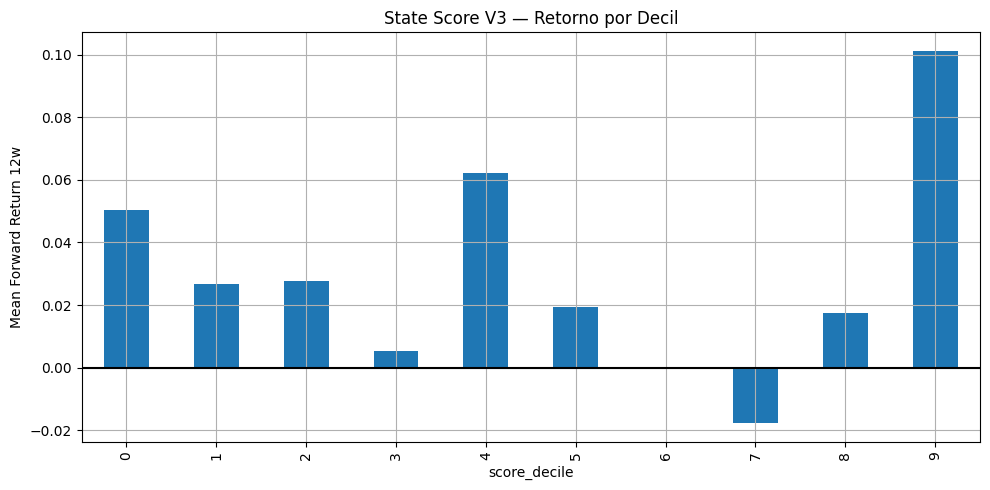

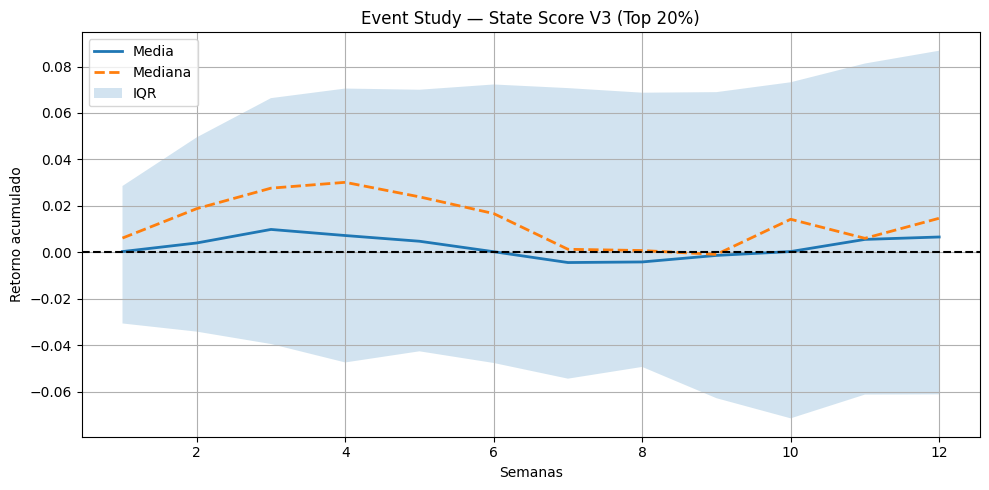

Eventos: 85  |  12w mean return: +0.0066


,mean,median
week,,
1,0.0003,0.0061
2,0.0040,0.0188
3,0.0098,0.0276
4,0.0072,0.0301
5,0.0048,0.0239
6,0.0002,0.0167
7,-0.0044,0.0013
8,-0.0042,0.0008
9,-0.0014,-0.0009


{'event_count': 85,
 'mean_path': array([ 0.00030928,  0.00401185,  0.00983902,  0.00721748,  0.00475583,
         0.00024677, -0.0044163 , -0.00416277, -0.00135344,  0.00031757,
         0.00554589,  0.00658608]),
 'median_path': array([ 0.00612715,  0.01879047,  0.02762029,  0.03013254,  0.02387667,
         0.01667339,  0.00129602,  0.00075625, -0.00091202,  0.01422375,
         0.00601812,  0.01465552]),
 'paths': array([[-0.0609779 , -0.13954715, -0.15892267, ..., -0.4515377 ,
         -0.34703241, -0.26159739],
        [-0.08367135, -0.10430508, -0.16848041, ..., -0.30463022,
         -0.21364726, -0.26644994],
        [-0.07164864, -0.15291131, -0.18193377, ..., -0.18102688,
         -0.12570329, -0.1737708 ],
        ...,
        [ 0.03467279,  0.01109155,  0.051923  , ...,  0.03372915,
          0.0683427 ,  0.03531625],
        [-0.02279101,  0.01667214, -0.04215861, ...,  0.0325416 ,
          0.00062189,  0.02746732],
        [-0.02278901, -0.02673658,  0.01732828, ...,  0.

In [25]:
# ============================================================
# STATE SCORE V3
# ============================================================

score_df = df.copy()
score_df = score_df.loc[state_df.index].copy()

score_df["atr_rank"]   = pd.qcut(score_df["atr_pct"],       5, labels=False)
score_df["bull_rank"]  = pd.qcut(score_df["pred_prob_bull"], 5, labels=False, duplicates="drop")
score_df["trend_rank"] = pd.qcut(score_df["trend_13_52"],    5, labels=False, duplicates="drop")

# Pesos iniciales V3
score_df["state_score_v3"] = (
    0.4 * score_df["atr_rank"] +
    0.4 * score_df["bull_rank"] +
    0.2 * score_df["trend_rank"]
)

score_df["score_decile"] = pd.qcut(
    score_df["state_score_v3"], 10, labels=False, duplicates="drop"
)

score_returns = score_df.groupby("score_decile")["fwd_ret_12"].mean()

corr_v3, p_v3 = spearmanr(
    score_df["state_score_v3"].dropna(),
    score_df.loc[score_df["state_score_v3"].notna(), "fwd_ret_12"]
)

print(f"State Score V3 — Spearman vs fwd_ret_12: {corr_v3:.4f}  (p={p_v3:.6f})")
print(f"Top-Bottom spread: {score_returns.iloc[-1] - score_returns.iloc[0]:+.4f}")

plt.figure(figsize=(10, 5))
score_returns.plot(kind="bar")
plt.axhline(0, color="black"); plt.title("State Score V3 — Retorno por Decil")
plt.ylabel("Mean Forward Return 12w"); plt.grid(True); plt.tight_layout(); plt.show()

# Event Study V3
run_event_study(
    score_df.assign(signal_v3=(score_df["state_score_v3"] >= score_df["state_score_v3"].quantile(0.8)).astype(int)),
    "signal_v3", "returns", 12,
    "Event Study — State Score V3 (Top 20%)"
)


---
## ⚡ Parte 11 — Optimización de Pesos del Score
### BLOQUE 13 — Grid search y score óptimo

Los pesos del BLOQUE 12 son razonables pero no necesariamente los mejores.
Realizamos un **barrido exhaustivo** sobre todas las combinaciones de pesos
con `w_atr + w_bull + w_trend = 1` (paso de 0.1):

```python
for w_atr in [0.0, 0.1, ..., 1.0]:
    for w_bull in [0.0, ..., 1.0 - w_atr]:
        w_trend = 1 - w_atr - w_bull
        score = w_atr × atr_rank + w_bull × bull_rank + w_trend × trend_rank
        spearman(score, fwd_ret_12)
```

> **Nota de muestra:** el grid search opera sobre el subconjunto de ~323 observaciones
> donde existe `pred_prob_bull`, consistente con las Partes 8–10. El Spearman
> resultante corresponde a ese período específico, no al histórico completo (~1315 obs).

> **Limitación explícita (data snooping):** el grid search optimiza y evalúa
> sobre el mismo dataset. El Spearman del score "óptimo" está inflado por
> esta selección — probando 66 combinaciones, encontrar el máximo ex-post
> no equivale a descubrir el mejor predictor real. Los pesos óptimos deben
> tratarse como hipótesis a validar sobre datos futuros, no como resultado
> confirmado. En producción se separaría train/validation antes de evaluar.


Top 10 combinaciones de pesos:


,atr,bull,trend,spearman,pvalue
6,0.0,0.6,0.4,0.1212,0.0225
7,0.0,0.7,0.3,0.1208,0.0230
5,0.0,0.5,0.5,0.1187,0.0255
17,0.1,0.6,0.3,0.1101,0.0385
16,0.1,0.5,0.4,0.1094,0.0396
15,0.1,0.4,0.5,0.1079,0.0424
8,0.0,0.8,0.2,0.1066,0.0450
9,0.0,0.9,0.1,0.1048,0.0488
4,0.0,0.4,0.6,0.1038,0.0510
25,0.2,0.4,0.4,0.1028,0.0533



Pesos óptimos: ATR=0.0  BULL=0.6  TREND=0.4
Spearman óptimo: 0.1212

Comparación final:
  ATR solo   : Spearman = -0.0323
  Score V3   : Spearman = 0.0579
  Score Opt  : Spearman = 0.1212
  Mejora sobre ATR: +0.1535


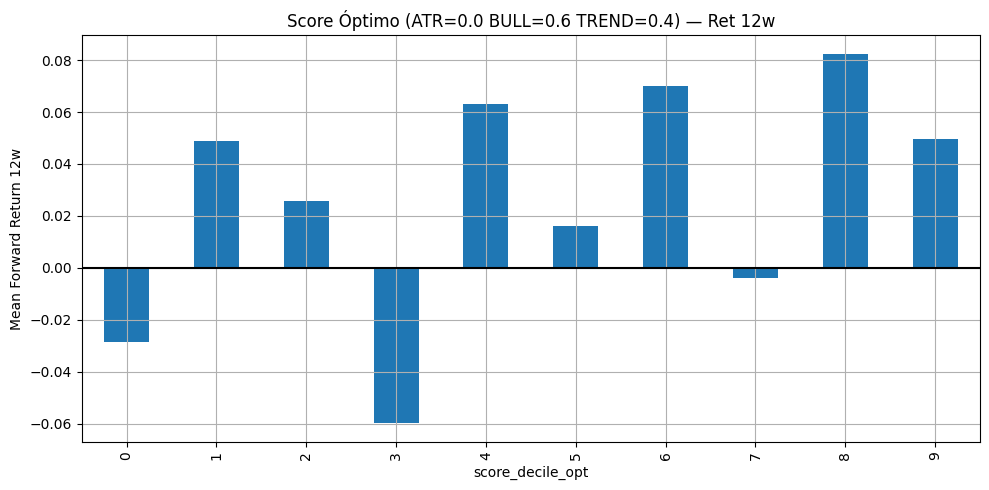

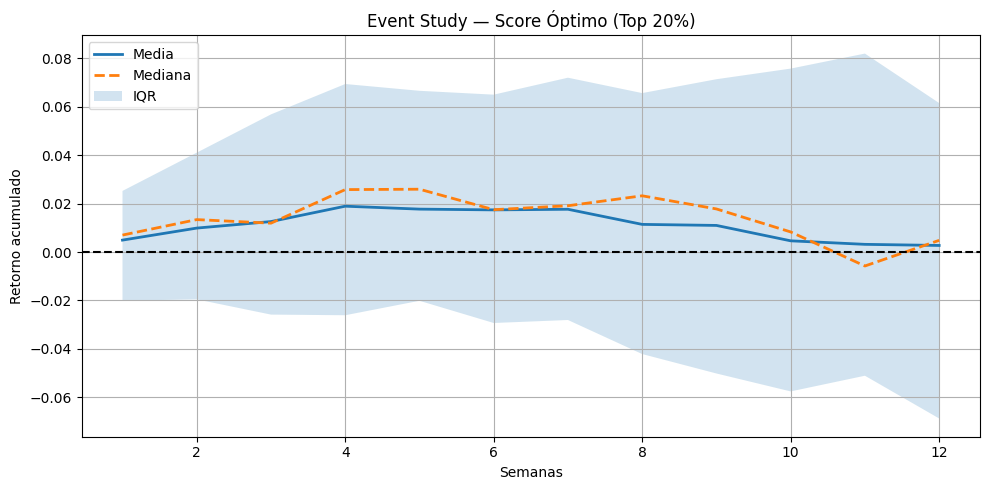

Eventos: 84  |  12w mean return: +0.0027


,mean,median
week,,
1,0.0049,0.0070
2,0.0099,0.0134
3,0.0126,0.0119
4,0.0190,0.0258
5,0.0177,0.0260
6,0.0174,0.0175
7,0.0177,0.0191
8,0.0114,0.0233
9,0.0110,0.0178



  RESUMEN FINAL — PARTE 2
  Regresión (RF)    : Spearman = -0.0645
  Clasificador Top10%: AUC = 0.7310
  Horizonte óptimo  : 24w  (AUC=0.8314)
  Score óptimo      : Spearman = 0.1212  (mejora: +0.1535)


In [26]:
# ============================================================
# GRID SEARCH — PESOS ÓPTIMOS
# ============================================================

weights = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results_gs = []

for w_atr in weights:
    for w_bull in weights:
        for w_trend in weights:
            if abs(w_atr + w_bull + w_trend - 1.0) > 1e-9:
                continue
            score = (
                w_atr   * score_df["atr_rank"]  +
                w_bull  * score_df["bull_rank"] +
                w_trend * score_df["trend_rank"]
            )
            corr, p = spearmanr(score, score_df["fwd_ret_12"])
            results_gs.append([w_atr, w_bull, w_trend, corr, p])

grid_df = pd.DataFrame(results_gs, columns=["atr","bull","trend","spearman","pvalue"])
grid_df = grid_df.sort_values("spearman", ascending=False)

print("Top 10 combinaciones de pesos:")
display(grid_df.head(10).round(4))

best = grid_df.iloc[0]
print(f"\nPesos óptimos: ATR={best['atr']}  BULL={best['bull']}  TREND={best['trend']}")
print(f"Spearman óptimo: {best['spearman']:.4f}")

# ── Score óptimo ─────────────────────────────────────────

score_df["state_score_opt"] = (
    best["atr"]   * score_df["atr_rank"]  +
    best["bull"]  * score_df["bull_rank"] +
    best["trend"] * score_df["trend_rank"]
)

score_df["score_decile_opt"] = pd.qcut(
    score_df["state_score_opt"], 10, labels=False, duplicates="drop"
)

deciles_opt  = score_df.groupby("score_decile_opt")["fwd_ret_12"].mean()
corr_opt, _  = spearmanr(score_df["state_score_opt"], score_df["fwd_ret_12"])
corr_atr, _  = spearmanr(score_df["atr_rank"],        score_df["fwd_ret_12"])

print(f"\nComparación final:")
print(f"  ATR solo   : Spearman = {corr_atr:.4f}")
print(f"  Score V3   : Spearman = {corr_v3:.4f}")
print(f"  Score Opt  : Spearman = {corr_opt:.4f}")
print(f"  Mejora sobre ATR: {corr_opt - corr_atr:+.4f}")

# Plot deciles score óptimo
plt.figure(figsize=(10, 5))
deciles_opt.plot(kind="bar")
plt.axhline(0, color="black")
plt.title(f"Score Óptimo (ATR={best['atr']} BULL={best['bull']} TREND={best['trend']}) — Ret 12w")
plt.ylabel("Mean Forward Return 12w"); plt.grid(True); plt.tight_layout(); plt.show()

# Event Study — Score óptimo
score_df["signal_opt"] = (
    score_df["state_score_opt"] >= score_df["state_score_opt"].quantile(0.80)
).astype(int)

run_event_study(score_df, "signal_opt", "returns", 12,
                "Event Study — Score Óptimo (Top 20%)")

# ── Resumen final ─────────────────────────────────────────

print("\n" + "="*60)
print("  RESUMEN FINAL — PARTE 2")
print("="*60)
print(f"  Regresión (RF)    : Spearman = {spearman_rf:.4f}")
print(f"  Clasificador Top10%: AUC = {auc10:.4f}")
print(f"  Horizonte óptimo  : {summary_h.iloc[0]['horizon']}w  (AUC={summary_h.iloc[0]['auc']:.4f})")
print(f"  Score óptimo      : Spearman = {corr_opt:.4f}  (mejora: {corr_opt-corr_atr:+.4f})")
print("="*60)


---
## 📋 Parte 12 — Conclusiones
### BLOQUE 14 — Resumen de hallazgos


In [27]:
# =========================================================
# RESUMEN EJECUTIVO DE HALLAZGOS — PARTE 2
# =========================================================

print(f"""
==============================================================
              CONCLUSIONES FINALES – PARTE 2
==============================================================

──────────────────────────────────────────────────────────

1. REGRESIÓN VS CLASIFICACIÓN

• Los modelos de regresión mostraron escaso poder predictivo
  sobre retorno continuo.

• Reformular como clasificación del top decil produjo señales
  más robustas. Los deciles de probabilidad se ordenan
  razonablemente con los retornos futuros (in-sample).

• Nota: la elección de Top10% vs Top20% fue ex-post — el
  AUC reportado incorpora esta selección.


2. HORIZONTE TEMPORAL

• Se evaluaron 4, 12 y 24 semanas. 24w mostró mayor AUC
  en el modelo clasificador.

• El proyecto mantiene fwd_ret_12 como horizonte operativo
  por consistencia con el resto del análisis y la Parte 1.


3. FACTORES INDIVIDUALES

• Los factores con mayor relación histórica (in-sample) con
  fwd_ret_12 son atr_pct y drawdown (evaluados en ~1315 obs).

• pred_prob_bull muestra relación en la submuestra ~323 obs,
  pero no es comparable directamente con los anteriores
  por la diferencia de tamaño y período histórico.


4. ESTADOS DE MERCADO

• La grilla ATR × Bull_bin produce combinaciones con retornos
  diferenciados.

• Signal A (umbrales elegidos ex-post) identifica estados que,
  en el historial, muestran mejores retornos relativos que
  otras combinaciones.

• Sin embargo, el backtest continuo no valida una ventaja
  operativa robusta. La señal más prometedora aparece en las
  transiciones de entrada (entry_only/event-driven).

• Estos umbrales deben tratarse como hipótesis: fueron
  seleccionados observando los mismos datos donde se evalúan.


5. EVENT STUDY

• Las transiciones de entrada a Signal A (entry_only) muestran
  retorno acumulado positivo a 12 semanas en media y mediana.

• El análisis all_weeks tiene ventanas solapadas — sus
  resultados no son estadísticamente independientes.


6. STATE SCORE Y GRID SEARCH

• El score compuesto mostró mayor Spearman que cada factor
  individual por separado (resultado in-sample).

• Spearman del score optimizado: {{corr_opt:.4f}}
  (pesos óptimos: ATR={{best['atr']}} BULL={{best['bull']}} TREND={{best['trend']}})
  Calculado sobre ~323 observaciones — subconjunto con cobertura de pred_prob_bull.
  IMPORTANTE: este Spearman está sobreestimado por optimización sobre la misma
  muestra. No debe interpretarse como capacidad predictiva real hasta validar
  en datos futuros.


7. LECCIONES METODOLÓGICAS

• Clasificación > Regresión para este tipo de señal.
• Contexto (estado) > Factor individual (in-sample).
• Transición > Permanencia en estado (hipótesis a validar).
• Score continuo > Regla binaria (in-sample, sin validación).

• El edge potencial emerge de la combinación de factores,
  pero todos los resultados aquí son in-sample y requieren
  validación out-of-sample antes de cualquier aplicación.

8. ESTADO DEL PROYECTO

• QQQ Research – Parte 2

• Estado:
      COMPLETADO

• Resultado:
      La predicción directa de retornos fue rechazada como
      enfoque principal. Sin embargo, se identificaron estados,
      combinaciones de factores y scores compuestos con evidencia
      estadística suficiente para justificar una validación más
      rigurosa.

• Aprendizaje validado:
      El mercado parece responder mejor a estructuras de contexto,
      persistencia e interacción entre factores que a forecasts
      puntuales de retorno.

==============================================================
""")



              CONCLUSIONES FINALES – PARTE 2

──────────────────────────────────────────────────────────

1. REGRESIÓN VS CLASIFICACIÓN

• Los modelos de regresión mostraron escaso poder predictivo
  sobre retorno continuo.

• Reformular como clasificación del top decil produjo señales
  más robustas. Los deciles de probabilidad se ordenan
  razonablemente con los retornos futuros (in-sample).

• Nota: la elección de Top10% vs Top20% fue ex-post — el
  AUC reportado incorpora esta selección.


2. HORIZONTE TEMPORAL

• Se evaluaron 4, 12 y 24 semanas. 24w mostró mayor AUC
  en el modelo clasificador.

• El proyecto mantiene fwd_ret_12 como horizonte operativo
  por consistencia con el resto del análisis y la Parte 1.


3. FACTORES INDIVIDUALES

• Los factores con mayor relación histórica (in-sample) con
  fwd_ret_12 son atr_pct y drawdown (evaluados en ~1315 obs).

• pred_prob_bull muestra relación en la submuestra ~323 obs,
  pero no es comparable directamente con los anteriores
  por